In [3]:
from sklearn.impute import SimpleImputer
import pandas as pd
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
# ensure project root is on sys.path so we can import the module
sys.path.append(str(Path.cwd()))
# from load_data import load_data, add_dtypes
from feature_engineering import engineer_features
# import importlib, load_data
# importlib.reload(load_data)

Load Data 

In [4]:
import pandas as pd
from pathlib import Path

def add_dtypes(data):
    '''Returns data with dtypes correctly assigned.'''

    num_cols = ['encounter_id','patient_nbr','time_in_hospital', 'num_lab_procedures', \
                    'num_procedures', 'num_medications', 'number_outpatient', \
                        'number_emergency', 'number_inpatient', 'number_diagnoses']
    numeric_cols = [x for x in num_cols if x in data.columns]  
    categorical = data.columns.difference(numeric_cols)

    # assign dtypes to float to numeric columns
    data[numeric_cols] = data[numeric_cols].astype('float')

    # assign dtypes to object to categorical columns
    data[categorical] = data[categorical].astype('object')

    # return data
    return data

# function to load the data
def load_data(processed=True, file_path=None):
    '''Returns the data.
    processed: bool: type of data to load (raw or processed)
    file_path: str or Path: direct path to a CSV file to load
    '''
    if file_path is not None:
        data = pd.read_csv(str(file_path), na_values=["?"])
        return add_dtypes(data)

    try:
        module_dir = Path(__file__).resolve().parent
    except NameError:
        module_dir = Path.cwd()

    candidate_data_dirs = [
        module_dir / 'data',          # thesis/data (expected)
        module_dir.parent / 'data',   # fallback: Code/data
        Path.cwd() / 'data'           # fallback: current working dir/data
    ]

    file_stem = 'diabetic_data_preprocessed' if processed else 'diabetic_data'
    rel_paths = [Path(f'{file_stem}.csv'), Path(file_stem)]

    data_path = None
    checked_paths = []
    for data_dir in candidate_data_dirs:
        for rel_path in rel_paths:
            candidate = data_dir / rel_path
            checked_paths.append(str(candidate))
            if candidate.exists():
                data_path = candidate
                break
        if data_path is not None:
            break

    # read the CSV (raise a clear error if missing)
    if data_path is None:
        raise FileNotFoundError(
            "Data file not found. Checked:\n- " + "\n- ".join(checked_paths)
        )

    data = pd.read_csv(str(data_path), na_values=["?"])
    return add_dtypes(data)

In [20]:
# determine base_path dynamically from current working directory (or a parent)
cwd = Path.cwd()
def find_base(start=cwd):
    for p in [start] + list(start.parents):
        if (p / "thesis").exists() or (p / "data").exists():
            return p
    return cwd

base_path = find_base()
print("Base path determined as:", base_path)

df_train = load_data(file_path=base_path / "data" / "diabetic_data_preprocessed_train.csv")
df_pategan = load_data(file_path=base_path / "data" / "pategan" / "diabetic_data_pategan_train_synthetic.csv")
df_healthgan = load_data(file_path=base_path / "data" / "healthgan" / "samples_99999_5_64_synthetic_0_decoded.csv")
df_pythia = load_data(file_path=base_path / "data" / "pythia" / "diabetic_data_pythia_train_synthetic.csv")
df_test = load_data(file_path=base_path / "data" / "diabetic_data_preprocessed_test.csv")
# Print the shapes as a sanity check
print("df_train shape:", df_train.shape)
print("df_pategan shape:", df_pategan.shape)
print("df_healthgan shape:", df_healthgan.shape)
print("df_pythia shape:", df_pythia.shape)


Base path determined as: /Users/kazimostafashahriar/Main Drive/thesis/Medical data analysis/Code/thesis
df_train shape: (57214, 45)
df_pategan shape: (57214, 45)
df_healthgan shape: (57214, 45)
df_pythia shape: (57214, 45)


In [4]:
#show all columns in the dataframe
pd.set_option('display.max_columns', None)

df_train.sample(2)

,encounter_id,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
46741,436212782.0,0,1.5,0,0,14,2.0,21.0,0.0,12.0,0.0,0.0,0.0,0,0,0,9.0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,1
41832,433173542.0,0,2.0,0,0,14,9.0,48.0,1.0,22.0,0.0,0.0,4.0,8,0,0,9.0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1


In [5]:
df_pategan.sample(2)

,encounter_id,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
34968,196879410.0,0,1.5,1,0,14,6.102568,71.044860,2.974755,23.116299,9.659698,44.506138,9.343219,1,1,1,11.132792,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1
47683,202884690.0,1,1.5,1,19,5,6.666929,37.735283,3.030024,67.603940,25.691391,47.238680,13.317455,6,1,7,6.358373,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,1


In [6]:
df_healthgan.sample(2)

,encounter_id,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
10718,72752996.0,0,1.0,0,0,14,4.0,52.0,0.0,10.0,0.0,0.0,0.0,0,7,1,9.0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
258,181184218.0,0,2.0,0,0,14,2.0,62.0,0.0,9.0,0.0,0.0,0.0,7,0,0,9.0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0


In [17]:
df_raw = load_data(processed=False)

/var/folders/zf/pdy3c0hs5zl3f4wx2fjycvsm0000gn/T/ipykernel_48709/1407984716.py:64: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(str(data_path), na_values=["?"])


In [2]:
df = load_data(processed=True)


In [4]:
df.sample(15)

,encounter_id,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
6300,39443748.0,0,1.5,0,0,14,8.0,83.0,6.0,33.0,...,0,1,0,0,0,0,0,0,1,1
18430,57732540.0,0,2.0,4,19,5,8.0,24.0,1.0,22.0,...,0,1,0,0,0,0,0,0,1,0
58350,237591222.0,0,1.0,0,0,14,4.0,43.0,1.0,12.0,...,0,0,0,0,0,0,0,1,1,0
57334,43112118.0,1,1.0,2,0,0,1.0,21.0,1.0,10.0,...,0,1,0,0,0,0,0,1,1,0
24431,83887938.0,0,1.0,4,0,5,3.0,1.0,1.0,16.0,...,0,0,0,0,0,0,0,1,1,0
15838,74584536.0,1,1.5,2,0,11,2.0,31.0,6.0,19.0,...,0,1,0,0,0,0,0,0,1,0
64783,215602980.0,1,2.0,0,5,14,5.0,51.0,0.0,15.0,...,0,0,0,0,0,0,0,1,0,0
62497,99880878.0,0,1.0,2,0,0,3.0,27.0,2.0,19.0,...,0,1,0,0,0,0,0,1,1,1
69423,327225086.0,1,1.0,0,0,14,12.0,78.0,6.0,37.0,...,0,1,0,0,0,0,0,0,1,0
23626,37362624.0,0,1.0,4,0,5,2.0,19.0,0.0,10.0,...,0,1,0,0,0,0,0,0,1,1


In [7]:
df.dtypes

encounter_id                float64
gender                       object
age                          object
admission_type_id            object
discharge_disposition_id     object
admission_source_id          object
time_in_hospital            float64
num_lab_procedures          float64
num_procedures              float64
num_medications             float64
number_outpatient           float64
number_emergency            float64
number_inpatient            float64
diag_1                       object
diag_2                       object
diag_3                       object
number_diagnoses            float64
max_glu_serum                object
A1Cresult                    object
metformin                    object
repaglinide                  object
nateglinide                  object
chlorpropamide               object
glimepiride                  object
acetohexamide                object
glipizide                    object
glyburide                    object
tolbutamide                 

In [5]:
df_raw.sample(15)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
27779,91031214.0,391644.0,Caucasian,Female,[70-80),NaN,1,1,7,8.0,...,No,Steady,No,No,No,No,No,No,Yes,NO
51380,153315654.0,85136535.0,Caucasian,Male,[70-80),NaN,1,1,1,1.0,...,No,No,No,No,No,No,No,No,Yes,>30
18715,67376796.0,2505159.0,Caucasian,Female,[40-50),NaN,3,6,6,6.0,...,No,Steady,No,No,No,No,No,No,Yes,NO
69402,197183046.0,90466101.0,Caucasian,Female,[40-50),NaN,1,1,7,2.0,...,No,No,No,No,No,No,No,No,No,NO
99265,411375128.0,91091043.0,Caucasian,Female,[70-80),NaN,3,1,1,1.0,...,No,Steady,No,No,No,No,No,Ch,Yes,<30
57859,164583696.0,90052641.0,Caucasian,Male,[50-60),NaN,2,1,7,2.0,...,No,Up,No,No,No,No,No,Ch,Yes,>30
49478,149749728.0,59196699.0,AfricanAmerican,Female,[60-70),NaN,1,22,7,4.0,...,No,No,No,No,No,No,No,No,Yes,NO
33079,104907522.0,5268978.0,AfricanAmerican,Male,[40-50),NaN,2,1,1,8.0,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
10279,43735578.0,18638118.0,Caucasian,Female,[70-80),NaN,1,18,7,6.0,...,No,Steady,No,No,No,No,No,No,Yes,>30
81045,250552344.0,965016.0,NaN,Male,[60-70),NaN,3,1,1,3.0,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [56]:
df = engineer_features(df)

In [57]:
df.columns

Index(['encounter_id', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [12]:
def summarize(df: pd.DataFrame):
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print("\nDtypes:\n" + df.dtypes.to_string())
    nulls = df.isna().sum()
    if nulls.any():
        print("\nMissing values (non-zero):")
        print(nulls[nulls > 0].sort_values(ascending=False).to_string())
    else:
        print("\nMissing values: none")

    try:
        mem = df.memory_usage(deep=True).sum()
        print(f"\nApprox. memory usage: {mem/1024/1024:.2f} MB")
    except Exception:
        pass
    print("\nPreview:")
    display(df.head(5))
    print("\n" + "-" * 80)

In [ ]:
# # Load CSVs and show structure
# base = "/Users/kazimostafashahriar/Main Drive/thesis/Medical data analysis/Code"
# path_diabetic = f"{base}/diabetic_data.csv"
# path_ids = f"{base}/IDS_mapping.csv"

# # Read

# df = pd.read_csv(path_diabetic, na_values=["?"])
# ids_df = pd.read_csv(path_ids, na_values=["?"])



/var/folders/zf/pdy3c0hs5zl3f4wx2fjycvsm0000gn/T/ipykernel_42610/3125645934.py:8: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path_diabetic, na_values=["?"])


In [9]:
df = load_data(processed=False)

/var/folders/zf/pdy3c0hs5zl3f4wx2fjycvsm0000gn/T/ipykernel_33284/3523505406.py:31: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(base+'/data/diabetic_data.csv', na_values=["?"])


In [13]:
summarize(df)

Shape: (101766, 50)
Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Dtypes:
encounter_id                float64
patient_nbr                 float64
race                         object
gender                       object


Shape: (101766, 50)
Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Dtypes:
encounter_id                float64
patient_nbr                 float64
race                         object
gender                       object


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392.0,8222157.0,Caucasian,Female,[0-10),NaN,6,25,1,1.0,...,No,No,No,No,No,No,No,No,No,NO
1,149190.0,55629189.0,Caucasian,Female,[10-20),NaN,1,1,7,3.0,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410.0,86047875.0,AfricanAmerican,Female,[20-30),NaN,1,1,7,2.0,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364.0,82442376.0,Caucasian,Male,[30-40),NaN,1,1,7,2.0,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680.0,42519267.0,Caucasian,Male,[40-50),NaN,1,1,7,1.0,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



--------------------------------------------------------------------------------


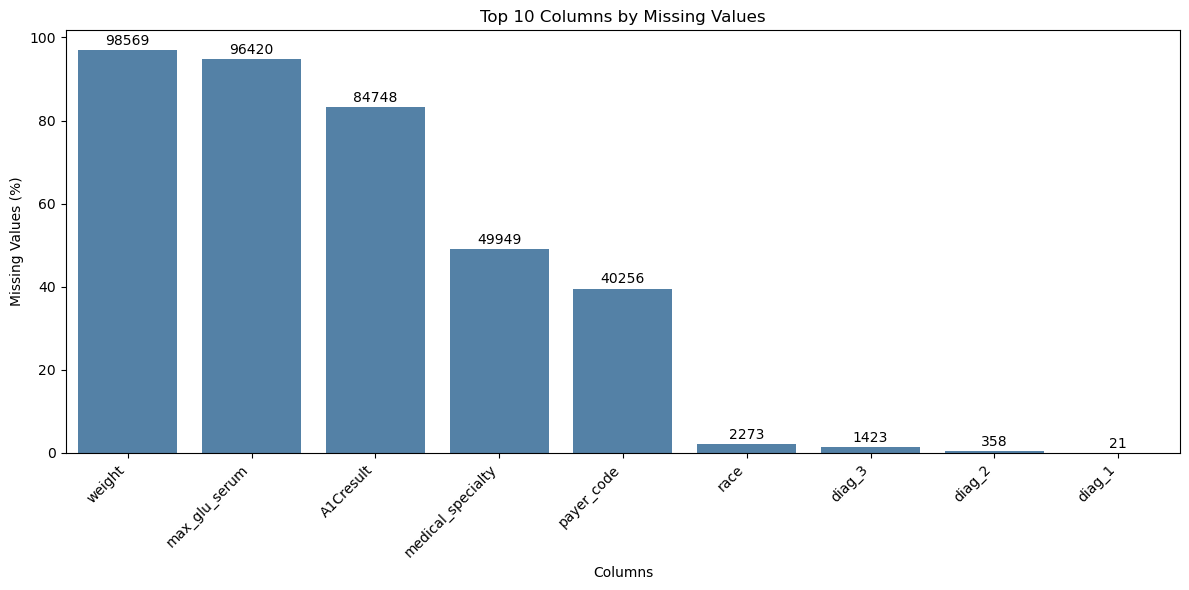

In [19]:

missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False).head(10)

if missing_counts.empty:
    print("No missing values found.")
else:
    missing_pct = (missing_counts / len(df)) * 100

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=missing_counts.index, y=missing_pct.values, color="steelblue")

    ax.set_title("Top 10 Columns by Missing Values")
    ax.set_xlabel("Columns")
    ax.set_ylabel("Missing Values (%)")
    plt.xticks(rotation=45, ha="right")

    # exact missing counts above each bar
    for i, (pct, cnt) in enumerate(zip(missing_pct.values, missing_counts.values)):
        ax.text(i, pct + 0.5, f"{cnt}", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()


In [8]:

missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False).head(10)

if missing_counts.empty:
    print("No missing values found.")
else:
    missing_pct = (missing_counts / len(df)) * 100

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=missing_counts.index, y=missing_pct.values, color="steelblue")

    ax.set_title("Top 10 Columns by Missing Values")
    ax.set_xlabel("Columns")
    ax.set_ylabel("Missing Values (%)")
    plt.xticks(rotation=45, ha="right")

    # exact missing counts above each bar
    for i, (pct, cnt) in enumerate(zip(missing_pct.values, missing_counts.values)):
        ax.text(i, pct + 0.5, f"{cnt}", ha="center", va="bottom", fontsize=10)

    plt.tight_layout()
    plt.show()


No missing values found.


In [21]:
# python
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold

def zero_variance_cols(df):
    """Return list of columns with zero variance (single unique value)."""
    return [c for c in df.columns if df[c].nunique(dropna=False) <= 1]

def near_zero_variance_cols(df, freq_ratio_thresh=20.0, unique_pct_thresh=10.0):
    """
    Detect near-zero-variance (NZV) columns (caret-style).
    - freq_ratio_thresh: ratio top / 2nd_top above which a column is NZV (default ~20).
    - unique_pct_thresh: percent unique values < this threshold considered NZV (default 10%).
    Works for categorical/object columns; numeric columns treated by unique pct.
    Returns a DataFrame with stats and a boolean 'is_nzv'.
    """
    n = len(df)
    rows = []
    for col in df.columns:
        ser = df[col].dropna().astype(str)
        nunique = ser.nunique()
        unique_pct = (nunique / n) * 100.0
        top_counts = ser.value_counts().values
        top = int(top_counts[0]) if top_counts.size > 0 else 0
        second = int(top_counts[1]) if top_counts.size > 1 else 0
        freq_ratio = (top / second) if second > 0 else np.inf
        is_nzv = (freq_ratio >= freq_ratio_thresh) and (unique_pct <= unique_pct_thresh)
        rows.append({
            "col": col,
            "n_unique": nunique,
            "unique_pct": unique_pct,
            "top_count": top,
            "second_count": second,
            "freq_ratio": freq_ratio,
            "is_nzv": is_nzv
        })
    return pd.DataFrame(rows).set_index("col").sort_values("is_nzv", ascending=False)

# sklearn helper for strictly zero-variance numeric columns
def sklearn_zero_variance(df):
    """Return zero-variance numeric columns using VarianceThreshold."""
    numeric = df.select_dtypes(include=[np.number])
    if numeric.shape[1] == 0:
        return []
    vt = VarianceThreshold(threshold=0.0)
    vt.fit(numeric.fillna(0))  # fillna to compute variance
    support = vt.get_support()
    zero_var_cols = numeric.columns[~support].tolist()
    return zero_var_cols

# Example usage:
# df = pd.read_csv("...") 
print("Zero-variance (single level):", zero_variance_cols(df))
print("SKLearn numeric zero-variance:", sklearn_zero_variance(df))
nzv_report = near_zero_variance_cols(df)
print(nzv_report[nzv_report["is_nzv"]])

Zero-variance (single level): ['examide', 'citoglipton']
SKLearn numeric zero-variance: []
                          n_unique  unique_pct  top_count  second_count  \
col                                                                       
repaglinide                      4    0.003931     100227          1384   
citoglipton                      1    0.000983     101766             0   
chlorpropamide                   4    0.003931     101680            79   
glimepiride                      4    0.003931      96575          4670   
acetohexamide                    2    0.001965     101765             1   
tolbutamide                      2    0.001965     101743            23   
acarbose                         4    0.003931     101458           295   
miglitol                         4    0.003931     101728            31   
troglitazone                     2    0.001965     101763             3   
examide                          1    0.000983     101766             0   
tolazamid

In [39]:
df["repaglinide"].value_counts(dropna=True)

repaglinide
No        100227
Steady      1384
Up           110
Down          45
Name: count, dtype: int64

In [38]:
df["gender"].isna().sum()

0

In [ ]:
def load_and_process_csv(csv_path, drop_thresh=0.5, fill_numeric='median', fill_categorical='mode'):
    """Load CSV from `csv_path` and perform basic processing.

    Steps performed:
    - read CSV with `na_values=['?']`
    - normalize column names (strip)
    - drop duplicate rows
    - drop columns with > `drop_thresh` fraction missing
    - trim whitespace from object columns
    - fill numeric NaNs with median (or 0)
    - fill categorical NaNs with mode (or 'missing')
    - attempt to apply `add_dtypes` if available

    Returns processed `pandas.DataFrame`.
    """
    import pandas as _pd
    import numpy as _np
    from pathlib import Path as _Path

    p = _Path(csv_path)
    if not p.exists():
        raise FileNotFoundError(f"CSV file not found: {csv_path}")

    df = _pd.read_csv(str(p), na_values=['?'])

    # normalize column names
    df.columns = [str(c).strip() for c in df.columns]

    # basic cleanup
    df = df.drop_duplicates()

    # drop columns with too many missing values
    missing_frac = df.isna().mean()
    drop_cols = missing_frac[missing_frac > drop_thresh].index.tolist()
    if drop_cols:
        df = df.drop(columns=drop_cols)

    # trim whitespace for object columns
    obj_cols = df.select_dtypes(include=['object']).columns.tolist()
    for c in obj_cols:
        df[c] = df[c].where(df[c].notna(), None)
        try:
            df[c] = df[c].astype(str).str.strip().replace({'None': None, 'nan': None})
        except Exception:
            pass

    # fill numeric columns
    num_cols = df.select_dtypes(include=[_np.number]).columns.tolist()
    for c in num_cols:
        if df[c].isna().any():
            if fill_numeric == 'median':
                df[c] = df[c].fillna(df[c].median())
            else:
                df[c] = df[c].fillna(0)

    # fill categorical columns
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    for c in cat_cols:
        if df[c].isna().any():
            if fill_categorical == 'mode':
                mode = df[c].mode(dropna=True)
                v = mode.iloc[0] if not mode.empty else 'missing'
                df[c] = df[c].fillna(v)
            else:
                df[c] = df[c].fillna('missing')

    # attempt to apply add_dtypes if available in the notebook
    try:
        df = add_dtypes(df)
    except Exception:
        pass

    df = df.reset_index(drop=True)
    print(f"Loaded {csv_path}: shape={df.shape}, dropped_columns={drop_cols}")
    return df


In [ ]:

# Value distribution comparison: df_train vs df_pategan_test
cols = df_train.columns.tolist()
n_cols = 5
n_rows = -(-len(cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    train_col = pd.to_numeric(df_train[col], errors='coerce')
    pate_col  = pd.to_numeric(df_pategan[col], errors='coerce')

    if train_col.notna().sum() > 0 and train_col.nunique() > 10:
        # Continuous numeric: KDE
        train_col.dropna().plot.kde(ax=ax, label='train', linewidth=1.5)
        pate_col.dropna().plot.kde(ax=ax, label='pategan', linewidth=1.5, linestyle='--')
    else:
        # Discrete / categorical: normalised bar chart
        t_counts = df_train[col].astype(str).value_counts(normalize=True).sort_index()
        p_counts = df_pategan[col].astype(str).value_counts(normalize=True).sort_index()
        all_vals = sorted(set(t_counts.index) | set(p_counts.index))
        t_vals = [t_counts.get(v, 0) for v in all_vals]
        p_vals = [p_counts.get(v, 0) for v in all_vals]
        x = range(len(all_vals))
        width = 0.4
        ax.bar([xi - width/2 for xi in x], t_vals, width=width, label='train', alpha=0.7)
        ax.bar([xi + width/2 for xi in x], p_vals, width=width, label='pategan', alpha=0.7)
        ax.set_xticks(list(x))
        ax.set_xticklabels(all_vals, rotation=45, ha='right', fontsize=7)

    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

# hide unused axes
for j in range(len(cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Value Distribution: df_train vs df_pategan_test", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
from pathlib import Path
import pandas as pd

# Resolve project root (works if notebook is in thesis/)
project_root = Path.cwd().parent if Path.cwd().name == "thesis" else Path.cwd()

base_path = project_root / "thesis"

# Load Pythia synthetic data
pythia_dir = base_path / "data" / "pythia"
train_path = pythia_dir / "diabetic_data_pythia_train_synthetic.csv"

df_pythia = pd.read_csv(train_path)
print("df_pythia shape:", df_pythia.shape)
df_pythia.sample(2)


Train: (57214, 45)
Test : (14304, 45)


,encounter_id,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,14858866.0,0,2.0,1,19,0,2.0,43.0,2.0,13.0,...,0,1,0,0,0,0,0,1,1,1
1,29142462.0,1,1.5,0,19,14,2.0,34.0,0.0,26.0,...,0,1,0,0,0,0,0,1,1,1
2,25143888.0,1,1.5,1,22,14,3.0,38.0,0.0,9.0,...,0,1,0,0,0,0,0,0,1,1
3,10498050.0,1,2.0,0,0,14,2.0,45.0,2.0,16.0,...,0,1,0,0,0,0,0,1,1,1
4,9162828.0,0,2.0,0,0,14,1.0,34.0,0.0,13.0,...,0,1,0,0,0,0,0,0,1,1


# Synthetic Data Analysis
## Comparing Real vs PATE-GAN vs HealthGAN vs Pythia

Analysis sections:
1. **Fidelity** — Statistical similarity (distributions, correlations, KS-tests)
2. **Utility** — Downstream ML performance (TSTR, Cox regression)
3. **Privacy** — Disclosure risk (DCR, nearest-neighbor distance)
4. **Comparative Summary** — Radar chart & metrics table


In [18]:
# ── Align all datasets to the same columns & numeric dtypes ──
# Drop ID columns that are not meaningful for analysis
id_cols = ['encounter_id', 'patient_nbr']

synthetic_datasets = {
    'PATE-GAN': df_pategan,
    'HealthGAN': df_healthgan,
    'Pythia': df_pythia,
}

# Use real training columns as the reference (minus IDs)
ref_cols = [c for c in df_train.columns if c not in id_cols]

# Align each synthetic dataset
for name, sdf in synthetic_datasets.items():
    missing = set(ref_cols) - set(sdf.columns)
    extra   = set(sdf.columns) - set(ref_cols) - set(id_cols)
    if missing:
        print(f"⚠️  {name} missing columns: {missing}")
    if extra:
        print(f"ℹ️  {name} extra columns (will drop): {extra}")

# Create analysis-ready copies (common columns only, cast to numeric)
def prepare_for_analysis(df, cols):
    """Keep only `cols`, coerce everything to numeric."""
    out = df[[c for c in cols if c in df.columns]].copy()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors='coerce')
    return out

real   = prepare_for_analysis(df_train, ref_cols)
pate   = prepare_for_analysis(df_pategan, ref_cols)
health = prepare_for_analysis(df_healthgan, ref_cols)
pythia = prepare_for_analysis(df_pythia, ref_cols)

synth_map = {'PATE-GAN': pate, 'HealthGAN': health, 'Pythia': pythia}

print(f"\nAnalysis columns ({len(ref_cols)}): {ref_cols[:10]}...")
print(f"Real: {real.shape}, PATE-GAN: {pate.shape}, HealthGAN: {health.shape}, Pythia: {pythia.shape}")



Analysis columns (44): ['gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient']...
Real: (57214, 44), PATE-GAN: (57214, 44), HealthGAN: (57214, 44), Pythia: (57214, 44)


## 1. Fidelity — Statistical Similarity


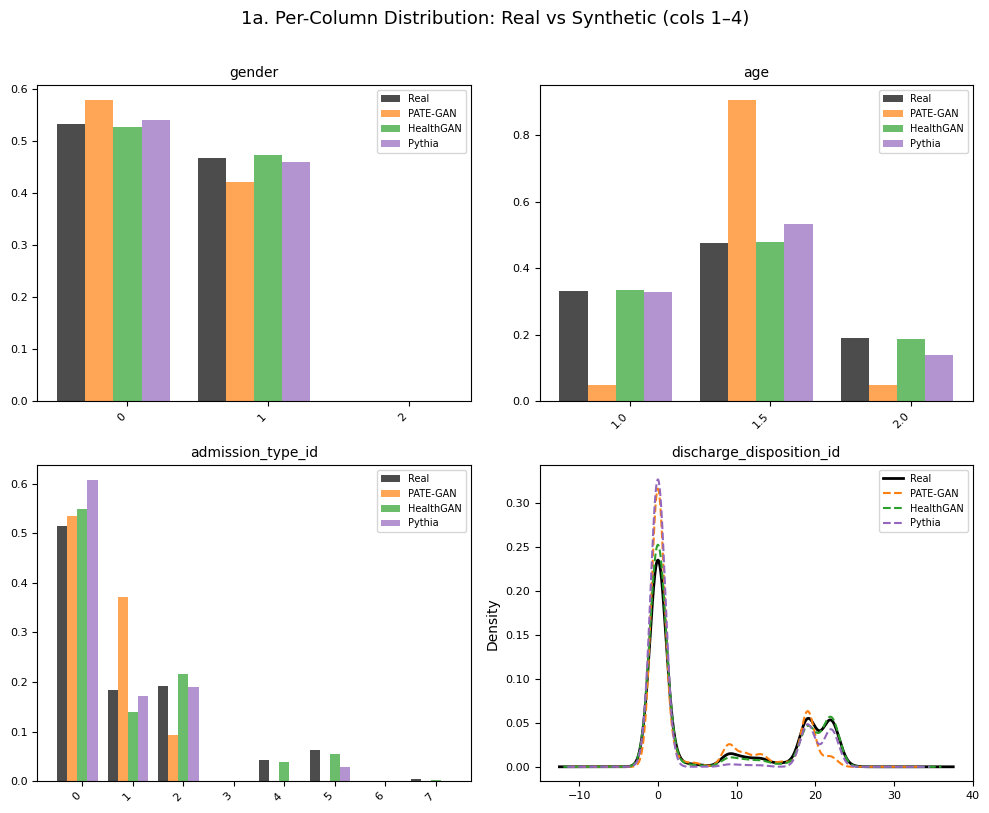

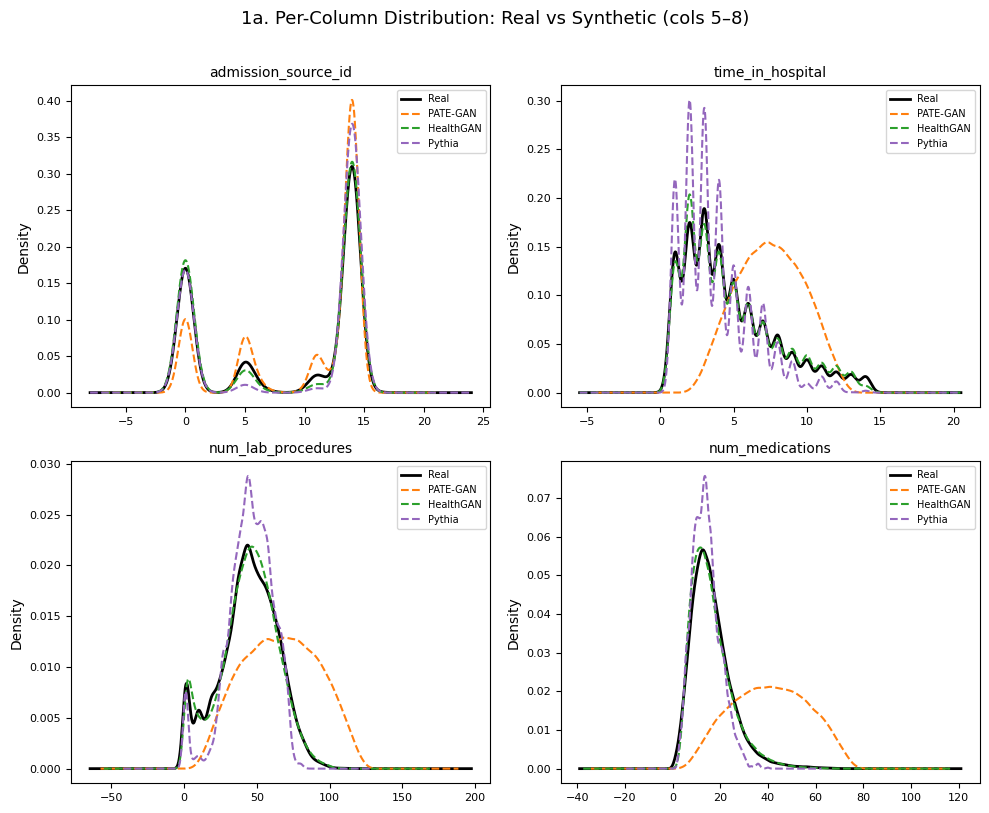

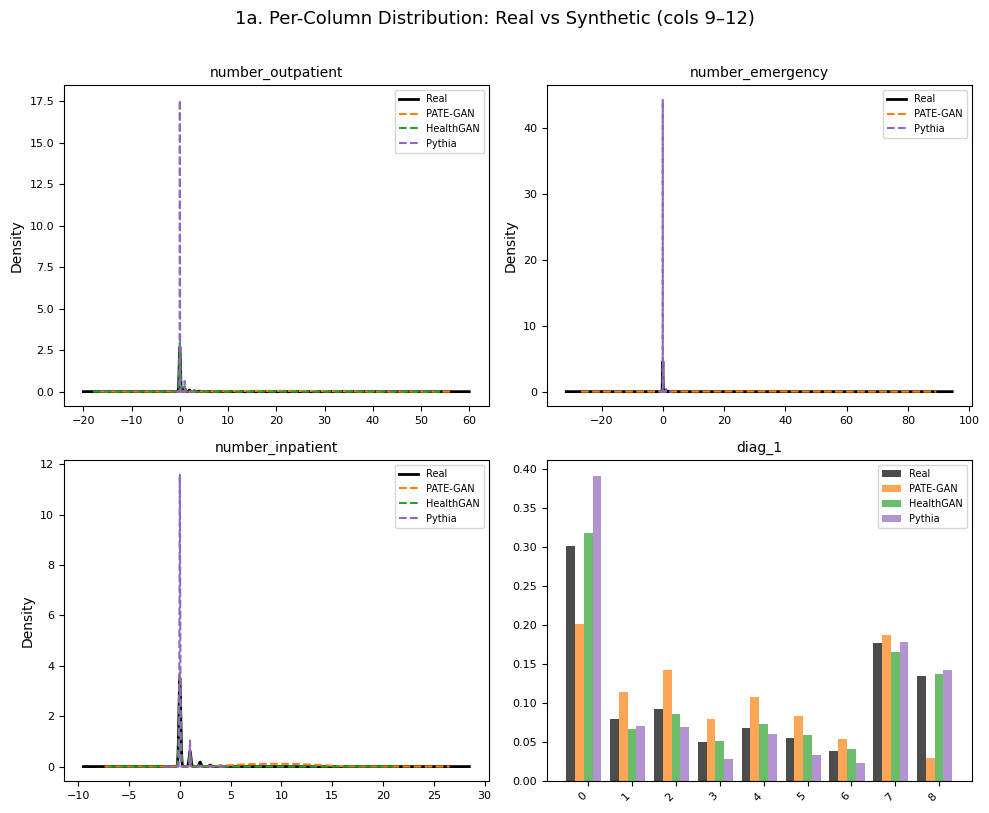

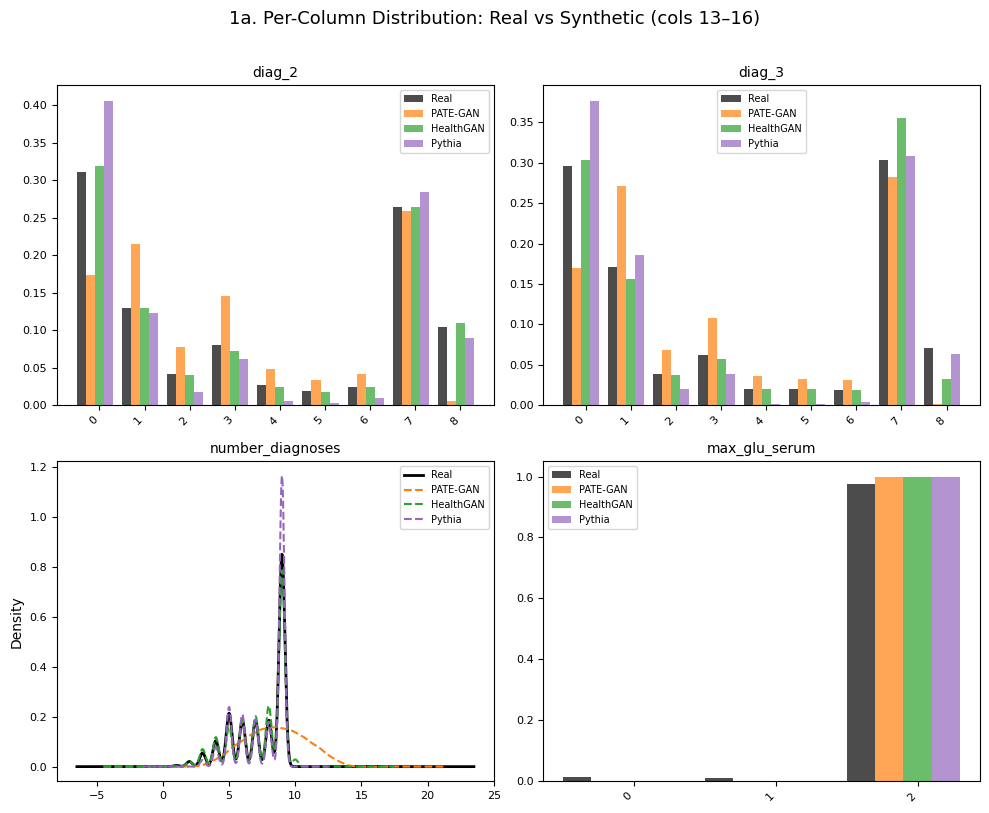

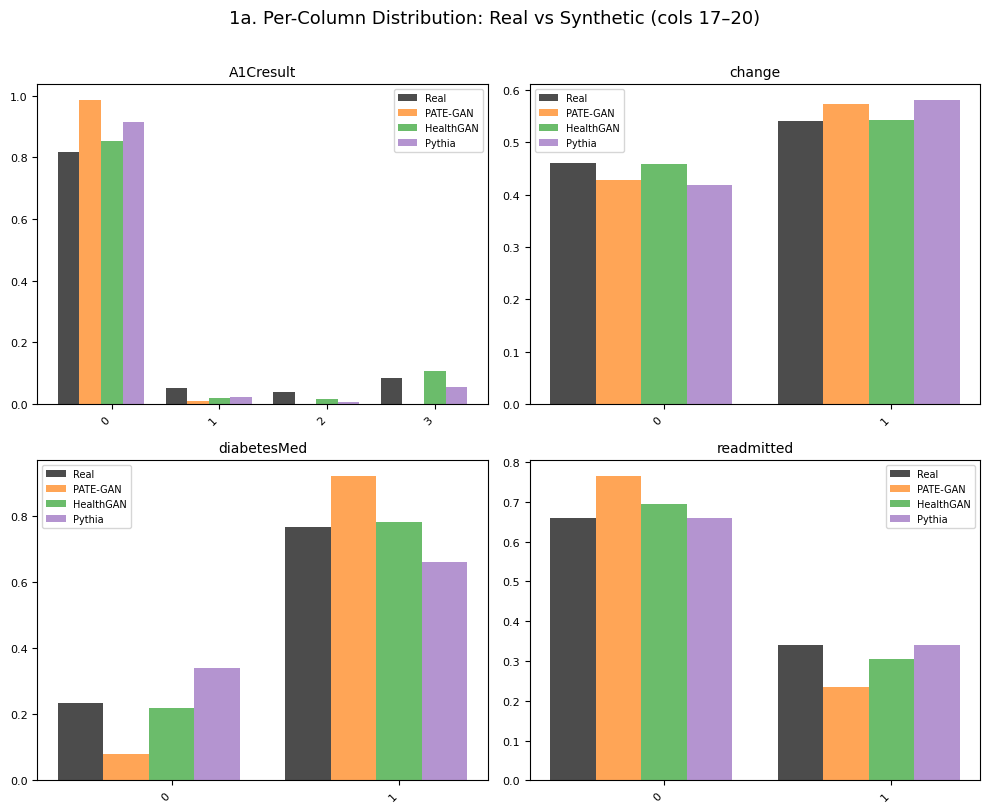

In [8]:
# 1a. Per-column distribution comparison: Real vs all synthetic generators
med_cols = {
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone',
}

cols = [c for c in ref_cols if c != "num_procedures" and c not in med_cols]

colors = {'PATE-GAN': 'tab:orange', 'HealthGAN': 'tab:green', 'Pythia': 'tab:purple'}
bar_colors = {'Real': 'black', **colors}

charts_per_fig = 4
n_cols_grid = 2
n_rows_grid = 2

for fig_idx in range(0, len(cols), charts_per_fig):
    batch = cols[fig_idx: fig_idx + charts_per_fig]
    fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(n_cols_grid * 5, n_rows_grid * 4))
    axes = axes.flatten()

    for i, col in enumerate(batch):
        ax = axes[i]
        real_col = real[col].dropna()

        if real_col.nunique() > 10:
            real_col.plot.kde(ax=ax, label='Real', color='black', linewidth=2)
            for name, sdf in synth_map.items():
                s_col = sdf[col].dropna()
                if len(s_col) > 1 and s_col.nunique() > 1:
                    s_col.plot.kde(ax=ax, label=name, color=colors[name], linewidth=1.5, linestyle='--')
        else:
            all_dfs = {'Real': real, **synth_map}
            all_labels = sorted(set().union(*(df[col].dropna().astype(str).unique() for df in all_dfs.values())))
            n_bars = len(all_dfs)
            width = 0.8 / n_bars
            for j, (name, sdf) in enumerate(all_dfs.items()):
                counts = sdf[col].astype(str).value_counts(normalize=True)
                vals = [counts.get(v, 0) for v in all_labels]
                x_pos = [xi + (j - n_bars / 2) * width for xi in range(len(all_labels))]
                ax.bar(x_pos, vals, width=width, label=name, color=bar_colors[name], alpha=0.7)
            ax.set_xticks(range(len(all_labels)))
            ax.set_xticklabels(all_labels, rotation=45, ha='right', fontsize=7)

        ax.set_title(col, fontsize=10)
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=8)

    for j in range(len(batch), len(axes)):
        axes[j].set_visible(False)

    start = fig_idx + 1
    end = min(fig_idx + charts_per_fig, len(cols))
    fig.suptitle(f"1a. Per-Column Distribution: Real vs Synthetic (cols {start}–{end})", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


In [24]:
# 1b. Summary statistics comparison (mean, std) — Real vs each synthetic
stats_rows = []
for col in [c for c in ref_cols if c != "num_procedures" and c not in med_cols]:
    row = {'column': col}
    for label, sdf in [('Real', real)] + list(synth_map.items()):
        s = sdf[col].dropna()
        row[f'{label}_mean'] = s.mean()
        row[f'{label}_std']  = s.std()
    stats_rows.append(row)

stats_df = pd.DataFrame(stats_rows).set_index('column')

# Filter: only keep columns where Real mean or std is non-zero
stats_df = stats_df[(stats_df['Real_mean'] != 0) | (stats_df['Real_std'] != 0)]

print("1b. Summary Statistics: Mean ± Std (non-zero Real values only)")
display(stats_df.style.format("{:.3f}").set_caption("Mean & Std per Column"))


1b. Summary Statistics: Mean ± Std (non-zero Real values only)


,Real_mean,Real_std,PATE-GAN_mean,PATE-GAN_std,HealthGAN_mean,HealthGAN_std,Pythia_mean,Pythia_std
column,,,,,,,,
gender,0.468,0.499,0.422,0.494,0.473,0.499,0.460,0.498
age,1.430,0.355,1.500,0.155,1.427,0.354,1.406,0.329
admission_type_id,1.082,1.495,0.558,0.659,1.014,1.436,0.701,1.086
discharge_disposition_id,6.875,9.186,4.742,7.566,6.345,9.155,4.519,8.415
admission_source_id,8.876,6.311,10.442,5.249,8.748,6.499,9.537,6.425
time_in_hospital,4.763,3.183,7.508,2.266,4.779,3.183,3.819,2.403
num_lab_procedures,44.181,19.964,66.579,25.591,44.181,19.915,45.392,15.461
num_medications,16.407,8.644,41.011,15.765,16.311,8.576,14.102,5.758
number_outpatient,0.305,1.127,20.000,7.015,0.222,1.057,0.037,0.195


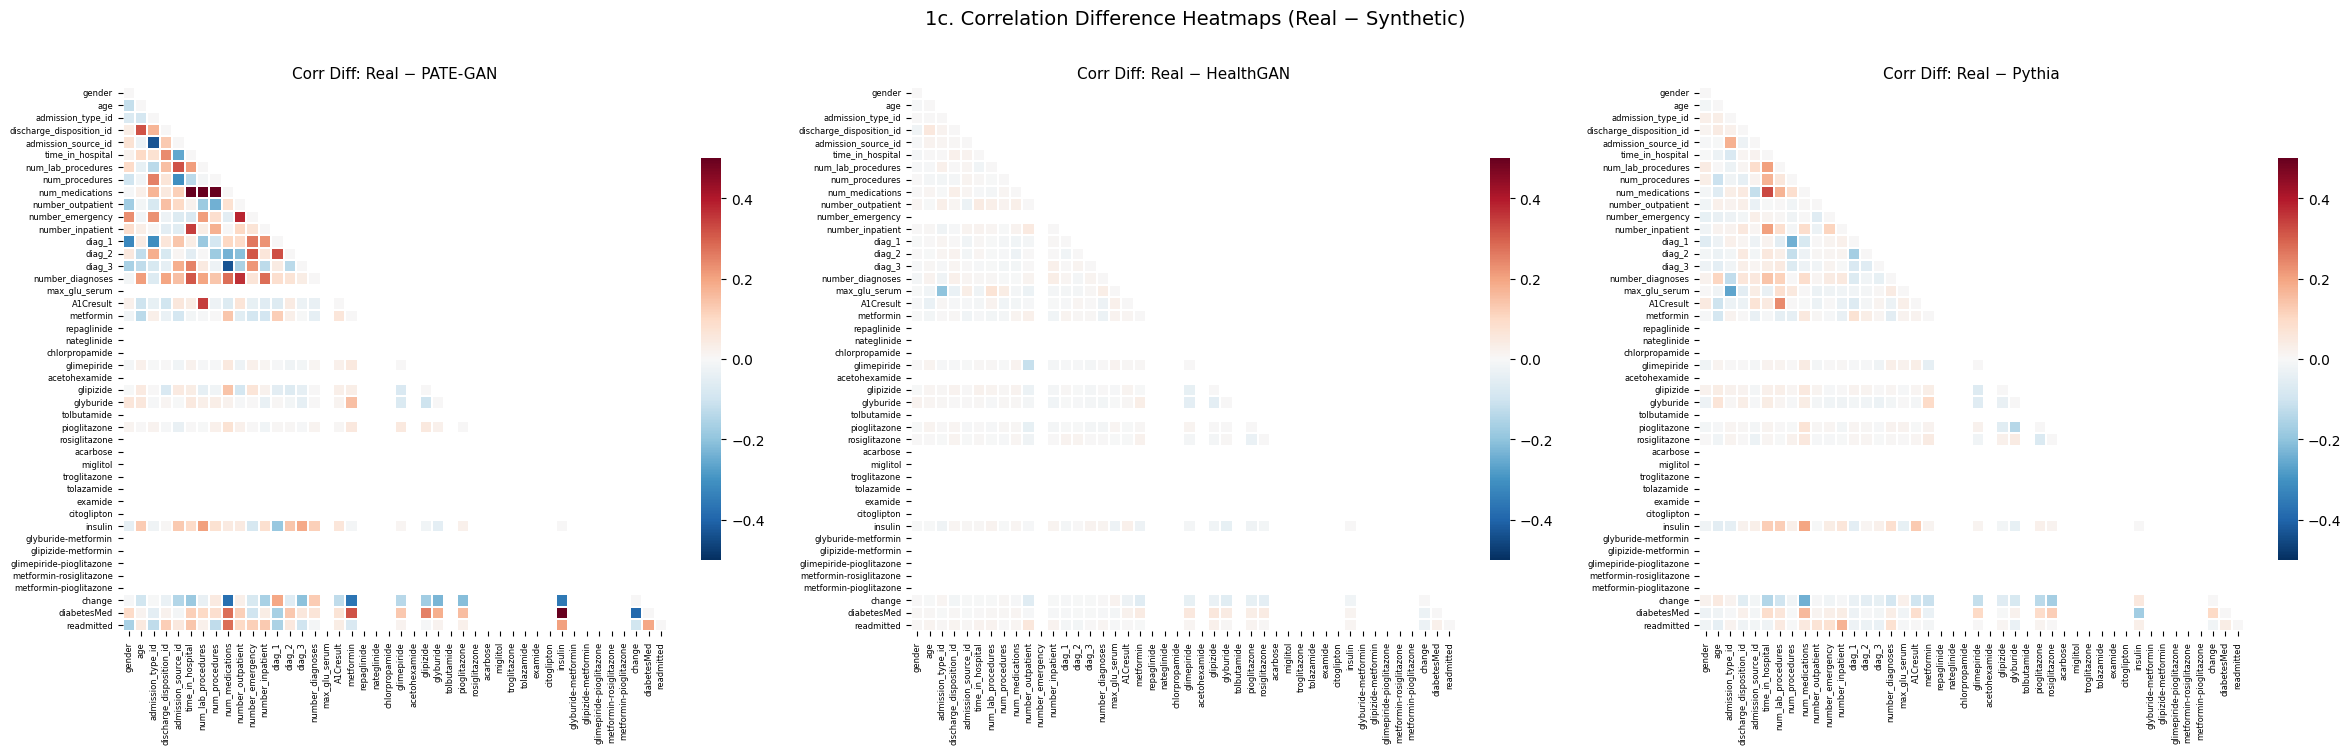


Mean Absolute Correlation Difference:
  PATE-GAN: nan
  HealthGAN: nan
  Pythia: nan


In [31]:
# 1c. Correlation matrix comparison & difference heatmaps
real_corr = real.corr()

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
for ax, (name, sdf) in zip(axes, synth_map.items()):
    synth_corr = sdf.corr()
    diff = real_corr - synth_corr
    mask = np.triu(np.ones_like(diff, dtype=bool), k=1)
    sns.heatmap(diff, mask=mask, cmap='RdBu_r', center=0, vmin=-0.5, vmax=0.5,
                ax=ax, square=True, linewidths=0.3, cbar_kws={'shrink': 0.7},
                xticklabels=True, yticklabels=True)
    ax.set_title(f"Corr Diff: Real − {name}", fontsize=11)
    ax.tick_params(labelsize=6)

fig.suptitle("1c. Correlation Difference Heatmaps (Real − Synthetic)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print mean absolute correlation difference per generator
print("\nMean Absolute Correlation Difference:")
for name, sdf in synth_map.items():
    diff = (real_corr - sdf.corr()).abs()
    mean_diff = diff.values[np.tril_indices_from(diff.values, k=-1)].mean()
    print(f"  {name}: {mean_diff:.4f}")


In [42]:
# 1d. Column-wise KS-test: Real vs each synthetic generator
from scipy.stats import ks_2samp

ks_rows = []
for col in [c for c in ref_cols if c not in med_cols]:
    row = {'column': col}
    real_vals = real[col].dropna().values
    for name, sdf in synth_map.items():
        synth_vals = sdf[col].dropna().values
        if len(synth_vals) > 0 and len(real_vals) > 0:
            stat, pval = ks_2samp(real_vals, synth_vals)
        else:
            stat, pval = np.nan, np.nan
        row[f'{name}_KS'] = stat
    ks_rows.append(row)

ks_df = pd.DataFrame(ks_rows).set_index('column')

print("1d. KS-Test Statistics (lower = more similar)")
display(ks_df.style.format("{:.4f}").set_caption("KS Statistic per Column"))

# Aggregate: mean KS statistic per generator
print("\nMean KS Statistic per Generator:")
for name in synth_map:
    mean_ks = ks_df[f'{name}_KS'].mean()
    print(f"  {name}: {mean_ks:.4f}")

1d. KS-Test Statistics (lower = more similar)


,PATE-GAN_KS,HealthGAN_KS,Pythia_KS
column,,,
gender,0.0462,0.0051,0.0082
age,0.2842,0.0028,0.0505
admission_type_id,0.2096,0.0349,0.0935
discharge_disposition_id,0.1182,0.0432,0.1681
admission_source_id,0.1534,0.0311,0.1220
time_in_hospital,0.5169,0.0170,0.1233
num_lab_procedures,0.3825,0.0162,0.0956
num_procedures,0.6159,0.0229,0.1086
num_medications,0.6903,0.0218,0.1241



Mean KS Statistic per Generator:
  PATE-GAN: 0.3456
  HealthGAN: 0.0255
  Pythia: 0.0870


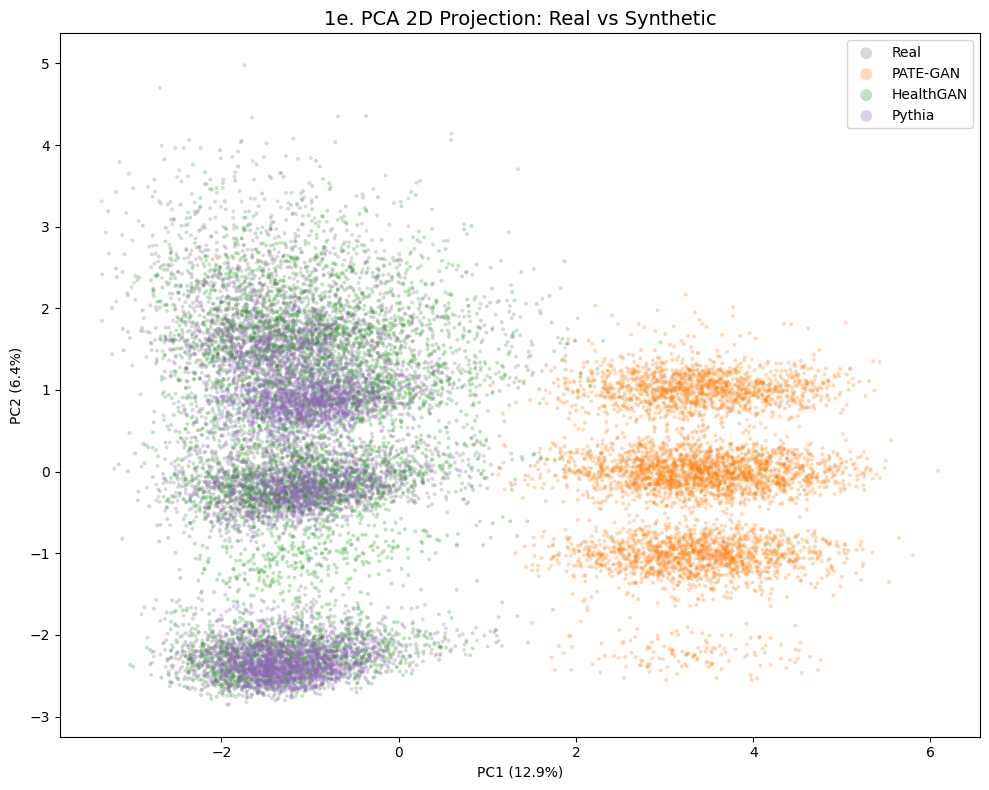

In [13]:
# 1e. PCA 2D projection: Real vs Synthetic (visual overlap check)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Sample for speed (max 5000 per dataset)
sample_n = min(5000, real.shape[0])
real_s = real.dropna().sample(n=sample_n, random_state=42)

combined = [real_s]
labels = ['Real'] * len(real_s)
colors_pca = {'Real': 'black', 'PATE-GAN': 'tab:orange', 'HealthGAN': 'tab:green', 'Pythia': 'tab:purple'}

for name, sdf in synth_map.items():
    s = sdf.dropna()
    n = min(sample_n, len(s))
    if n > 0:
        ss = s.sample(n=n, random_state=42)
        combined.append(ss)
        labels += [name] * len(ss)

all_data = pd.concat(combined, ignore_index=True).fillna(0)
scaler = StandardScaler()
scaled = scaler.fit_transform(all_data)

pca = PCA(n_components=2, random_state=42)
proj = pca.fit_transform(scaled)

fig, ax = plt.subplots(figsize=(10, 8))
label_arr = np.array(labels)
for name in ['Real', 'PATE-GAN', 'HealthGAN', 'Pythia']:
    mask = label_arr == name
    if mask.sum() > 0:
        alpha = 0.15 if name == 'Real' else 0.3
        ax.scatter(proj[mask, 0], proj[mask, 1], label=name, color=colors_pca[name],
                   alpha=alpha, s=8, edgecolors='none')

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("1e. PCA 2D Projection: Real vs Synthetic", fontsize=14)
ax.legend(markerscale=3, fontsize=10)
plt.tight_layout()
plt.show()


## 2. Utility — Downstream ML Performance

**TSTR** (Train on Synthetic, Test on Real): Train classifiers on each synthetic dataset, evaluate on real test data. Compare with TRTR (Train on Real, Test on Real) as the upper bound.


In [27]:
# 2a. TSTR — Train on Synthetic, Test on Real
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

TARGET = 'readmitted'

# Load real test set

test_prepared = prepare_for_analysis(df_test, ref_cols)

feature_cols = [c for c in ref_cols if c != TARGET]
X_test = test_prepared[feature_cols].values
y_test = test_prepared[TARGET].values

# Impute NaNs
imp = SimpleImputer(strategy='median')

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

# Training sources: Real (TRTR baseline) + each synthetic
train_sources = {'Real (TRTR)': real, **synth_map}

results = []
for src_name, src_df in train_sources.items():
    X_train_src = src_df[feature_cols].values
    y_train_src = src_df[TARGET].values

    # Drop rows with NaN target
    valid = ~np.isnan(y_train_src)
    X_train_src = X_train_src[valid]
    y_train_src = y_train_src[valid]

    X_train_imp = imp.fit_transform(X_train_src)
    X_test_imp = imp.transform(X_test)

    for clf_name, clf in classifiers.items():
        clf_copy = clf.__class__(**clf.get_params())
        clf_copy.fit(X_train_imp, y_train_src)
        y_pred = clf_copy.predict(X_test_imp)
        y_prob = clf_copy.predict_proba(X_test_imp)[:, 1] if hasattr(clf_copy, 'predict_proba') else y_pred

        results.append({
            'Train Source': src_name,
            'Classifier': clf_name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'F1': f1_score(y_test, y_pred, zero_division=0),
            'AUC-ROC': roc_auc_score(y_test, y_prob),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
        })

results_df = pd.DataFrame(results)
print("2a. TSTR Results: Train on Synthetic, Test on Real")
display(results_df.style.format({
    'Accuracy': '{:.4f}', 'F1': '{:.4f}', 'AUC-ROC': '{:.4f}',
    'Precision': '{:.4f}', 'Recall': '{:.4f}'
}).set_caption("TSTR Classification Metrics"))


2a. TSTR Results: Train on Synthetic, Test on Real


,Train Source,Classifier,Accuracy,F1,AUC-ROC,Precision,Recall
0,Real (TRTR),Logistic Regression,0.6806,0.2849,0.6671,0.5979,0.1870
1,Real (TRTR),Random Forest,0.6877,0.3616,0.6828,0.5936,0.2600
2,Real (TRTR),Gradient Boosting,0.6958,0.3644,0.7014,0.6301,0.2563
3,PATE-GAN,Logistic Regression,0.6361,0.1161,0.4997,0.3343,0.0703
4,PATE-GAN,Random Forest,0.6250,0.1318,0.4749,0.3102,0.0836
5,PATE-GAN,Gradient Boosting,0.6485,0.0437,0.4823,0.2934,0.0236
6,HealthGAN,Logistic Regression,0.6760,0.1963,0.6580,0.6282,0.1163
7,HealthGAN,Random Forest,0.6728,0.2435,0.6356,0.5705,0.1547
8,HealthGAN,Gradient Boosting,0.6792,0.2647,0.6605,0.6007,0.1697
9,Pythia,Logistic Regression,0.6243,0.4046,0.6128,0.4389,0.3753


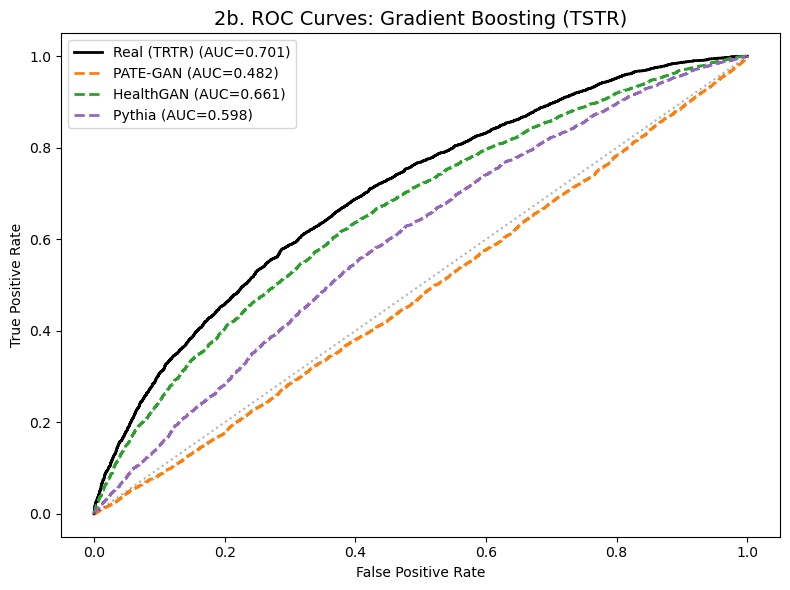

In [16]:
# 2b. ROC Curve Overlay (Gradient Boosting)
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))
roc_colors = {'Real (TRTR)': 'black', 'PATE-GAN': 'tab:orange', 'HealthGAN': 'tab:green', 'Pythia': 'tab:purple'}

for src_name, src_df in train_sources.items():
    X_train_src = src_df[feature_cols].values
    y_train_src = src_df[TARGET].values
    valid = ~np.isnan(y_train_src)
    X_train_src, y_train_src = X_train_src[valid], y_train_src[valid]

    X_train_imp = imp.fit_transform(X_train_src)
    X_test_imp = imp.transform(X_test)

    clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train_imp, y_train_src)
    y_prob = clf.predict_proba(X_test_imp)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ls = '-' if src_name == 'Real (TRTR)' else '--'
    ax.plot(fpr, tpr, label=f"{src_name} (AUC={auc:.3f})", color=roc_colors[src_name], linestyle=ls, linewidth=2)

ax.plot([0, 1], [0, 1], 'k:', alpha=0.3)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("2b. ROC Curves: Gradient Boosting (TSTR)", fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


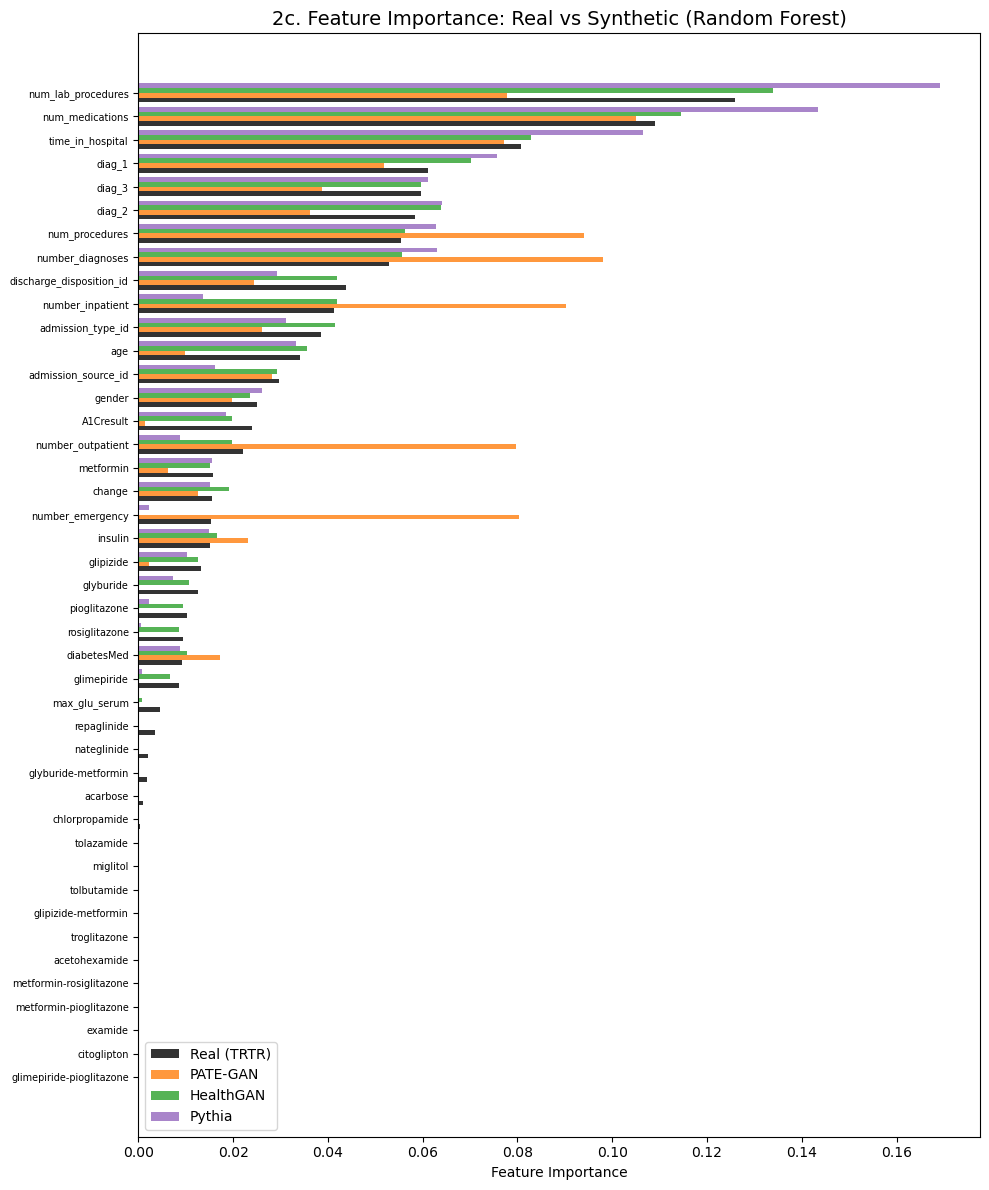

In [17]:
# 2c. Feature Importance Comparison (Random Forest)
fi_results = {}
for src_name, src_df in train_sources.items():
    X_train_src = src_df[feature_cols].values
    y_train_src = src_df[TARGET].values
    valid = ~np.isnan(y_train_src)
    X_train_src, y_train_src = X_train_src[valid], y_train_src[valid]

    X_train_imp = imp.fit_transform(X_train_src)
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train_imp, y_train_src)
    fi_results[src_name] = rf.feature_importances_

fi_df = pd.DataFrame(fi_results, index=feature_cols).sort_values('Real (TRTR)', ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
bar_width = 0.2
y_pos = np.arange(len(fi_df))
fi_colors = {'Real (TRTR)': 'black', 'PATE-GAN': 'tab:orange', 'HealthGAN': 'tab:green', 'Pythia': 'tab:purple'}

for i, (src_name, color) in enumerate(fi_colors.items()):
    if src_name in fi_df.columns:
        ax.barh(y_pos + i * bar_width, fi_df[src_name], height=bar_width,
                label=src_name, color=color, alpha=0.8)

ax.set_yticks(y_pos + bar_width * 1.5)
ax.set_yticklabels(fi_df.index, fontsize=7)
ax.set_xlabel("Feature Importance")
ax.set_title("2c. Feature Importance: Real vs Synthetic (Random Forest)", fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


### 2d. Cox Proportional Hazards Regression

Fit a Cox PH model on real and each synthetic dataset using `time_in_hospital` as the duration and `readmitted` as the event. Compare **hazard ratios (HR)** and **95% confidence intervals** across real and synthetic data. **Overlapping CIs** indicate the synthetic data preserves the same covariate–outcome relationships as the real data.


In [32]:
# 2d. Cox Proportional Hazards Regression — Real vs Synthetic
# pip install lifelines (if not already installed)
from lifelines import CoxPHFitter

DURATION = 'time_in_hospital'
EVENT = 'readmitted'

# Select clinically meaningful covariates for the Cox model
cox_covariates = [
    'age', 'gender', 'num_medications', 'num_lab_procedures',
    'num_procedures', 'number_diagnoses', 'number_inpatient',
    'number_emergency', 'number_outpatient', 'insulin',
    'diabetesMed', 'change', 'admission_type_id',
]
cox_cols = cox_covariates + [DURATION, EVENT]

# Fit Cox PH on each dataset
cox_results = {}
for src_name, src_df in [('Real', real)] + list(synth_map.items()):
    df_cox = src_df[[c for c in cox_cols if c in src_df.columns]].dropna().copy()
    # Replace infinities and ensure duration > 0 (Cox requirement)
    df_cox = df_cox.replace([np.inf, -np.inf], np.nan).dropna()
    df_cox = df_cox[df_cox[DURATION] > 0]

    # Drop zero-variance columns (cause convergence failure)
    zero_var = [c for c in df_cox.columns if c not in [DURATION, EVENT] and df_cox[c].nunique() <= 1]
    if zero_var:
        print(f"ℹ️  {src_name}: dropping zero-variance columns {zero_var}")
        df_cox = df_cox.drop(columns=zero_var)

    cph = CoxPHFitter(penalizer=0.01)
    try:
        cph.fit(df_cox, duration_col=DURATION, event_col=EVENT)
        summary = cph.summary[['exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%']].copy()
        summary.columns = ['HR', 'CI_lower', 'CI_upper']
        cox_results[src_name] = summary
        print(f"✓ Cox PH fitted on {src_name}: {len(df_cox)} rows, {len(summary)} covariates")
    except Exception as e:
        print(f"✗ Cox PH failed on {src_name}: {e}")

# Display the Real hazard ratios table
if 'Real' in cox_results:
    print("\nReal Data — Hazard Ratios:")
    display(cox_results['Real'].style.format("{:.3f}").set_caption("Real: Hazard Ratios & 95% CI"))

✓ Cox PH fitted on Real: 57214 rows, 13 covariates
✓ Cox PH fitted on PATE-GAN: 57214 rows, 13 covariates
ℹ️  HealthGAN: dropping zero-variance columns ['number_emergency']
✓ Cox PH fitted on HealthGAN: 57214 rows, 12 covariates
✓ Cox PH fitted on Pythia: 57214 rows, 13 covariates

Real Data — Hazard Ratios:


,HR,CI_lower,CI_upper
covariate,,,
age,0.815,0.783,0.848
gender,1.010,0.982,1.039
num_medications,0.963,0.961,0.965
num_lab_procedures,0.996,0.995,0.996
num_procedures,0.977,0.968,0.985
number_diagnoses,1.013,1.004,1.021
number_inpatient,1.030,1.016,1.043
number_emergency,1.054,1.043,1.064
number_outpatient,1.063,1.055,1.072


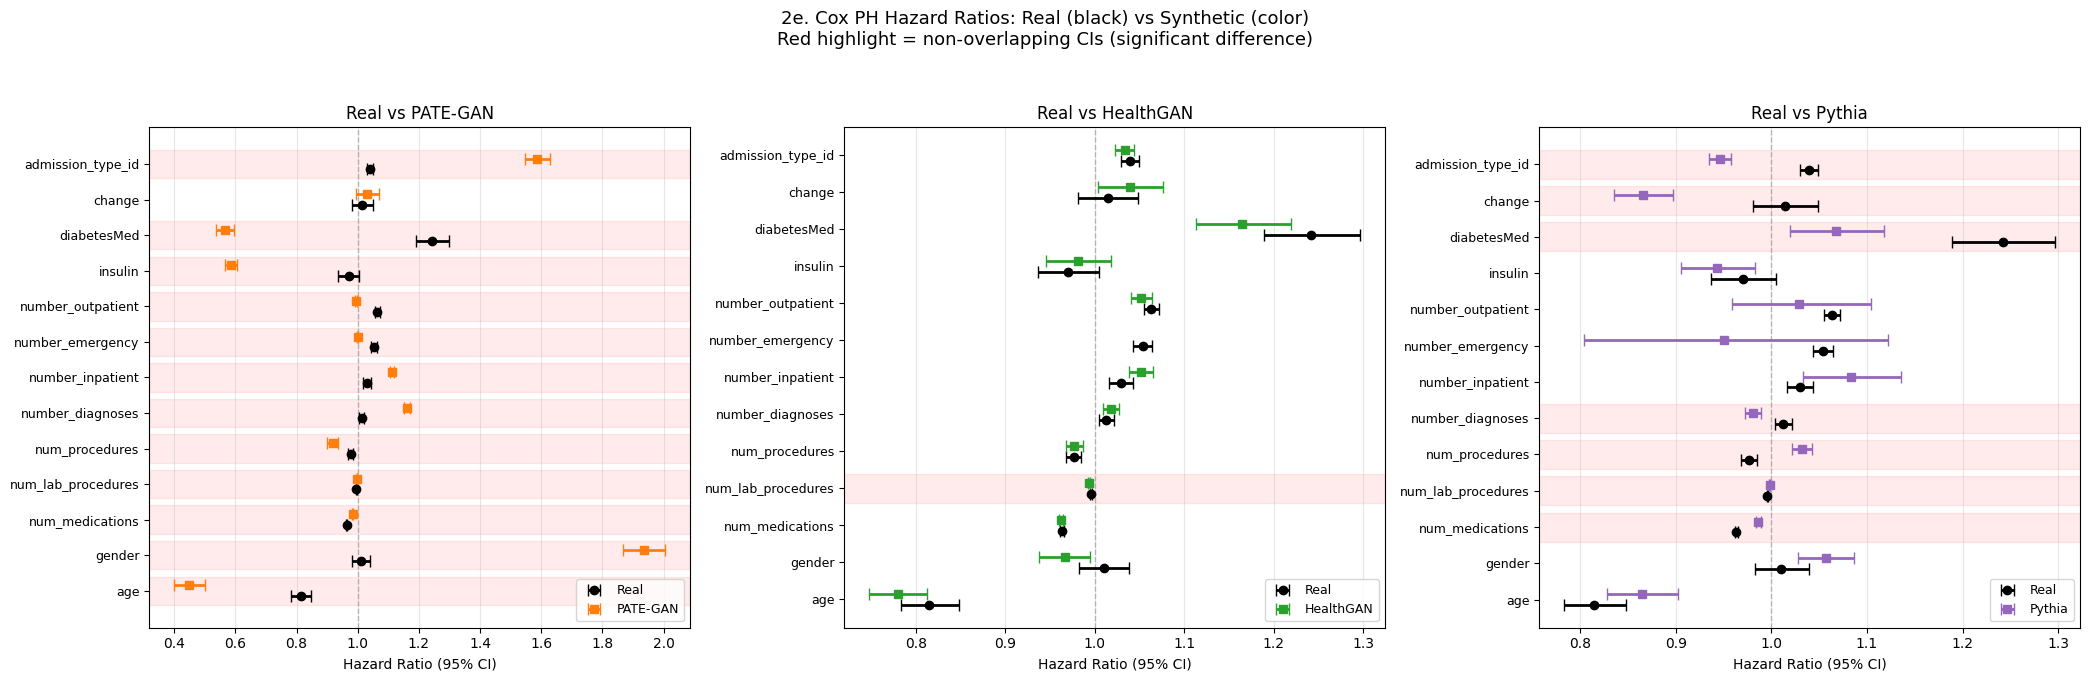


CI Overlap Summary:
  ⚠️  PATE-GAN — age: Real CI (0.783, 0.848) vs Synth CI (0.399, 0.501)
  ⚠️  PATE-GAN — gender: Real CI (0.982, 1.039) vs Synth CI (1.867, 2.006)
  ⚠️  PATE-GAN — num_medications: Real CI (0.961, 0.965) vs Synth CI (0.982, 0.985)
  ⚠️  PATE-GAN — num_lab_procedures: Real CI (0.995, 0.996) vs Synth CI (0.998, 0.999)
  ⚠️  PATE-GAN — num_procedures: Real CI (0.968, 0.985) vs Synth CI (0.899, 0.937)
  ⚠️  PATE-GAN — number_diagnoses: Real CI (1.004, 1.021) vs Synth CI (1.152, 1.171)
  ⚠️  PATE-GAN — number_inpatient: Real CI (1.016, 1.043) vs Synth CI (1.106, 1.119)
  ⚠️  PATE-GAN — number_emergency: Real CI (1.043, 1.064) vs Synth CI (0.999, 1.002)
  ⚠️  PATE-GAN — number_outpatient: Real CI (1.055, 1.072) vs Synth CI (0.992, 0.998)
  ⚠️  PATE-GAN — insulin: Real CI (0.937, 1.005) vs Synth CI (0.564, 0.606)
  ⚠️  PATE-GAN — diabetesMed: Real CI (1.189, 1.297) vs Synth CI (0.538, 0.596)
  ⚠️  PATE-GAN — admission_type_id: Real CI (1.030, 1.049) vs Synth CI (1.548, 1.

In [11]:
# 2e. Cox HR Confidence Interval Overlap Plot
# Real CI in black, each synthetic in color. Overlapping CIs = no significant difference.

if 'Real' in cox_results:
    real_hr = cox_results['Real']
    covariates = real_hr.index.tolist()

    synth_colors = {'PATE-GAN': 'tab:orange', 'HealthGAN': 'tab:green', 'Pythia': 'tab:purple'}

    fig, axes = plt.subplots(1, len(synth_colors), figsize=(7 * len(synth_colors), max(6, len(covariates) * 0.5)))

    for ax_idx, (synth_name, color) in enumerate(synth_colors.items()):
        ax = axes[ax_idx] if len(synth_colors) > 1 else axes
        y_pos = np.arange(len(covariates))

        # Real CIs (black)
        ax.errorbar(
            real_hr['HR'], y_pos - 0.15,
            xerr=[real_hr['HR'] - real_hr['CI_lower'], real_hr['CI_upper'] - real_hr['HR']],
            fmt='o', color='black', elinewidth=2, capsize=4, markersize=6, label='Real', zorder=3
        )

        # Synthetic CIs (color)
        if synth_name in cox_results:
            synth_hr = cox_results[synth_name]
            # Align to the same covariates
            common_covs = [c for c in covariates if c in synth_hr.index]
            synth_aligned = synth_hr.loc[common_covs]
            y_synth = [covariates.index(c) for c in common_covs]

            ax.errorbar(
                synth_aligned['HR'], np.array(y_synth) + 0.15,
                xerr=[synth_aligned['HR'] - synth_aligned['CI_lower'],
                      synth_aligned['CI_upper'] - synth_aligned['HR']],
                fmt='s', color=color, elinewidth=2, capsize=4, markersize=6, label=synth_name, zorder=3
            )

            # Mark non-overlapping CIs with a red background
            for c in common_covs:
                r = real_hr.loc[c]
                s = synth_aligned.loc[c]
                overlap = not (r['CI_upper'] < s['CI_lower'] or s['CI_upper'] < r['CI_lower'])
                if not overlap:
                    y_idx = covariates.index(c)
                    ax.axhspan(y_idx - 0.4, y_idx + 0.4, color='red', alpha=0.08, zorder=0)
        else:
            ax.text(0.5, 0.5, f'{synth_name} not available', transform=ax.transAxes, ha='center')

        # Reference line at HR=1 (no effect)
        ax.axvline(x=1, color='grey', linestyle='--', alpha=0.5, linewidth=1)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(covariates, fontsize=9)
        ax.set_xlabel("Hazard Ratio (95% CI)")
        ax.set_title(f"Real vs {synth_name}", fontsize=12)
        ax.legend(fontsize=9, loc='lower right')
        ax.grid(axis='x', alpha=0.3)

    fig.suptitle("2e. Cox PH Hazard Ratios: Real (black) vs Synthetic (color)\n"
                 "Red highlight = non-overlapping CIs (significant difference)",
                 fontsize=13, y=1.04)
    plt.tight_layout()
    plt.show()

    # Summary: count of non-overlapping CIs per generator
    print("\nCI Overlap Summary:")
    for synth_name in synth_colors:
        if synth_name in cox_results:
            synth_hr = cox_results[synth_name]
            common = [c for c in covariates if c in synth_hr.index]
            non_overlap = 0
            for c in common:
                r = real_hr.loc[c]
                s = synth_hr.loc[c]
                if r['CI_upper'] < s['CI_lower'] or s['CI_upper'] < r['CI_lower']:
                    non_overlap += 1
                    print(f"  ⚠️  {synth_name} — {c}: Real CI ({r['CI_lower']:.3f}, {r['CI_upper']:.3f}) "
                          f"vs Synth CI ({s['CI_lower']:.3f}, {s['CI_upper']:.3f})")
            print(f"  {synth_name}: {len(common) - non_overlap}/{len(common)} CIs overlap "
                  f"({'✓ all overlap' if non_overlap == 0 else f'{non_overlap} non-overlapping'})")


## 3. Privacy — Disclosure Risk

Evaluate privacy risk of synthetic data through four complementary metrics:
1. **Nearest-Neighbor Distances (+ NNDR)** — How close are synthetic records to real records in feature space? Large distances indicate privacy preservation.
2. **Membership Inference Attack (MIA)** — Can an adversary determine whether a specific individual was in the training set?
3. **Attribute Inference** — Can sensitive patient attributes be deduced from synthetic data with partial prior knowledge?
4. **Clustering Proximity** — Do synthetic samples cluster around real outlier individuals, exposing linkage risks?

In [15]:
# 3a. Nearest-Neighbor Distances & NNDR
from sklearn.neighbors import NearestNeighbors

# Prepare real data (scaled)
real_clean = real.dropna()
scaler_priv = StandardScaler()
real_scaled = scaler_priv.fit_transform(real_clean)

sample_priv = min(10000, real_clean.shape[0])

# Real→Real baseline (2nd NN, since 1st is itself)
nn_real = NearestNeighbors(n_neighbors=2, metric='euclidean', n_jobs=-1)
nn_real.fit(real_scaled)
real_real_dists, _ = nn_real.kneighbors(real_scaled)
real_real_nn = real_real_dists[:, 1]

nn_privacy = {}
s2r_distributions = {}  # store for visualization

for name, sdf in synth_map.items():
    s_clean = sdf.dropna()
    if len(s_clean) == 0:
        print(f"⚠️  {name}: no complete rows, skipping")
        continue

    s_sample = s_clean.sample(n=min(sample_priv, len(s_clean)), random_state=42)
    s_scaled = scaler_priv.transform(s_sample)

    # Real → Synthetic: for each real record, distance to closest synthetic record
    nn_synth = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1)
    nn_synth.fit(s_scaled)
    r2s_dists, _ = nn_synth.kneighbors(real_scaled[:sample_priv])
    r2s = r2s_dists[:, 0]

    # Synthetic → Real: for each synthetic record, distance to closest real record
    nn_real_lookup = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1)
    nn_real_lookup.fit(real_scaled)
    s2r_dists, _ = nn_real_lookup.kneighbors(s_scaled)
    s2r = s2r_dists[:, 0]
    s2r_distributions[name] = s2r

    # NNDR: ratio of synth→real distance to real→real distance
    real_sample = np.random.choice(real_real_nn, size=len(s2r), replace=True)
    nndr = s2r / (real_sample + 1e-10)

    nn_privacy[name] = {
        'Real→Synth median': np.median(r2s),
        'Real→Synth 5th pct': np.percentile(r2s, 5),
        'Synth→Real median': np.median(s2r),
        'Synth→Real 5th pct': np.percentile(s2r, 5),
        'NNDR median': np.median(nndr),
        'NNDR mean': np.mean(nndr),
    }

    print(f"✓ {name}: R→S median={np.median(r2s):.3f}, S→R median={np.median(s2r):.3f}, "
          f"NNDR median={np.median(nndr):.3f}")

nn_df = pd.DataFrame(nn_privacy).T
print("\n3a. Nearest-Neighbor Distance Summary:")
print("(Larger distances & NNDR ≥ 1 = better privacy)")
display(nn_df.style.format("{:.4f}").set_caption("Nearest-Neighbor Distances & NNDR"))

✓ PATE-GAN: R→S median=18.926, S→R median=19.426, NNDR median=9.536
✓ HealthGAN: R→S median=2.630, S→R median=2.091, NNDR median=1.020
✓ Pythia: R→S median=2.762, S→R median=1.567, NNDR median=0.771

3a. Nearest-Neighbor Distance Summary:
(Larger distances & NNDR ≥ 1 = better privacy)


,Real→Synth median,Real→Synth 5th pct,Synth→Real median,Synth→Real 5th pct,NNDR median,NNDR mean
PATE-GAN,18.9262,17.1282,19.4258,11.1923,9.5360,11.3717
HealthGAN,2.6299,1.3021,2.0910,0.9515,1.0196,1221.9615
Pythia,2.7624,1.1642,1.5674,0.7527,0.7712,0.9599


In [35]:
# 3a-ii. Nearest Neighbor Adversarial Accuracy (NNAA) — Yale et al. (HealthGAN paper)
# Measures whether synthetic and real data are indistinguishable via nearest-neighbor classification.
# AA = 0.5 * (mean(d_TS > d_TT) + mean(d_ST > d_SS))
# Target: AA ≈ 0.5 (indistinguishable). AA < 0.5 = synthetic too close to real (privacy risk).
# PrivacyLoss = TestAA - TrainAA  →  target ≈ 0.0

from sklearn.model_selection import train_test_split

# Split real data into train / test (80/20), mirroring the HealthGAN paper setup
real_clean_aa = real.dropna()
real_train_aa, real_test_aa = train_test_split(real_clean_aa, test_size=0.2, random_state=42)

scaler_aa = StandardScaler()
real_train_scaled = scaler_aa.fit_transform(real_train_aa)
real_test_scaled  = scaler_aa.transform(real_test_aa)

# Sample cap for speed
n_aa = min(5000, len(real_train_scaled), len(real_test_scaled))
real_train_s = real_train_scaled[:n_aa]
real_test_s  = real_test_scaled[:n_aa]

def adversarial_accuracy(t_data, s_data):
    """
    AA_TS = 0.5 * ( mean(d_TS > d_TT) + mean(d_ST > d_SS) )
    d_TS: distance from each point in T to its nearest neighbor in S
    d_TT: distance from each point in T to its nearest neighbor in T (excl. self)
    """
    # d_TT: fit on T, query T (exclude self → 2nd neighbor)
    nn_tt = NearestNeighbors(n_neighbors=2, metric='euclidean', n_jobs=-1).fit(t_data)
    d_tt = nn_tt.kneighbors(t_data)[0][:, 1]

    # d_TS: fit on S, query T
    nn_ts = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1).fit(s_data)
    d_ts = nn_ts.kneighbors(t_data)[0][:, 0]

    # d_SS: fit on S, query S (exclude self)
    nn_ss = NearestNeighbors(n_neighbors=2, metric='euclidean', n_jobs=-1).fit(s_data)
    d_ss = nn_ss.kneighbors(s_data)[0][:, 1]

    # d_ST: fit on T, query S
    nn_st = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1).fit(t_data)
    d_st = nn_st.kneighbors(s_data)[0][:, 0]

    left  = np.mean(d_ts > d_tt)   # fraction of T points closer to T than to S
    right = np.mean(d_st > d_ss)   # fraction of S points closer to S than to T
    return 0.5 * (left + right)

nnaa_results = {}

for name, sdf in synth_map.items():
    s_clean = sdf.dropna()
    if len(s_clean) == 0:
        continue

    s_sample = s_clean.sample(n=min(n_aa, len(s_clean)), random_state=42)
    s_scaled  = scaler_aa.transform(s_sample)

    train_aa = adversarial_accuracy(real_train_s, s_scaled)
    test_aa  = adversarial_accuracy(real_test_s,  s_scaled)
    privacy_loss = test_aa - train_aa

    nnaa_results[name] = {
        'Train AA (ResemblLoss)': train_aa,
        'Test AA  (ResemblLoss)': test_aa,
        'Privacy Loss':           privacy_loss,
    }

    print(f"✓ {name}: TrainAA={train_aa:.4f}, TestAA={test_aa:.4f}, PrivacyLoss={privacy_loss:.4f}")

nnaa_df = pd.DataFrame(nnaa_results).T
print("\n3a-ii. Nearest Neighbor Adversarial Accuracy (NNAA):")
print("(Train/Test AA ≈ 0.5 = good resemblance & privacy;  PrivacyLoss ≈ 0.0 = no memorisation)")
display(nnaa_df.style.format("{:.4f}").set_caption("NNAA — Yale et al. metric (HealthGAN paper)"))

✓ PATE-GAN: TrainAA=1.0000, TestAA=0.9998, PrivacyLoss=-0.0002
✓ HealthGAN: TrainAA=0.5688, TestAA=0.5671, PrivacyLoss=-0.0017
✓ Pythia: TrainAA=0.6863, TestAA=0.6866, PrivacyLoss=0.0003

3a-ii. Nearest Neighbor Adversarial Accuracy (NNAA):
(Train/Test AA ≈ 0.5 = good resemblance & privacy;  PrivacyLoss ≈ 0.0 = no memorisation)


,Train AA (ResemblLoss),Test AA (ResemblLoss),Privacy Loss
PATE-GAN,1.0000,0.9998,-0.0002
HealthGAN,0.5688,0.5671,-0.0017
Pythia,0.6863,0.6866,0.0003


In [36]:
# 3b. Membership Inference Attack (MIA)
# An adversary tries to determine if a specific individual was in the training set.
# Method: distance-based features relative to synthetic data for members (train) vs non-members (test).
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import cross_val_predict

# Prepare test data (non-members)
test_clean = prepare_for_analysis(df_test, ref_cols).dropna()
test_scaled = scaler_priv.transform(test_clean)

# Balance member / non-member sample sizes
n_mia = min(5000, len(real_scaled), len(test_scaled))
member_scaled = real_scaled[:n_mia]       # training data = members
nonmember_scaled = test_scaled[:n_mia]    # test data = non-members

mia_results = {}

for name, sdf in synth_map.items():
    s_clean = sdf.dropna()
    if len(s_clean) == 0:
        continue

    s_sample = s_clean.sample(n=min(sample_priv, len(s_clean)), random_state=42)
    s_scaled = scaler_priv.transform(s_sample)

    # Fit NN on synthetic data (K=5 for richer features)
    nn_synth_mia = NearestNeighbors(n_neighbors=5, metric='euclidean', n_jobs=-1)
    nn_synth_mia.fit(s_scaled)

    # Compute distance features for members and non-members
    member_dists, _ = nn_synth_mia.kneighbors(member_scaled)
    nonmember_dists, _ = nn_synth_mia.kneighbors(nonmember_scaled)

    def mia_features(dists):
        return np.column_stack([dists[:, 0], dists[:, 2], dists[:, 4], dists.mean(axis=1)])

    X_mia = np.vstack([mia_features(member_dists), mia_features(nonmember_dists)])
    y_mia = np.array([1] * len(member_dists) + [0] * len(nonmember_dists))

    # 5-fold cross-validated prediction
    clf_mia = LogisticRegression(max_iter=1000, random_state=42)
    y_prob_mia = cross_val_predict(clf_mia, X_mia, y_mia, cv=5, method='predict_proba')[:, 1]
    y_pred_mia = (y_prob_mia >= 0.5).astype(int)

    mia_auc = roc_auc_score(y_mia, y_prob_mia)
    mia_acc = accuracy_score(y_mia, y_pred_mia)
    mia_advantage = mia_auc - 0.5

    risk_level = 'High' if mia_advantage > 0.1 else 'Medium' if mia_advantage > 0.05 else 'Low'
    mia_results[name] = {
        'MIA AUC': mia_auc,
        'MIA Accuracy': mia_acc,
        'MIA Advantage': mia_advantage,
        'Privacy Risk': risk_level,
    }

    print(f"✓ {name}: MIA AUC={mia_auc:.4f}, Accuracy={mia_acc:.4f}, "
          f"Advantage={mia_advantage:.4f} → {risk_level}")

mia_df = pd.DataFrame(mia_results).T
print("\n3b. Membership Inference Attack Results:")
print("(AUC ≈ 0.5 = attacker cannot distinguish members → good privacy)")
print("(AUC >> 0.5 = attacker can identify training members → privacy risk)")
display(mia_df)

✓ PATE-GAN: MIA AUC=0.4962, Accuracy=0.4975, Advantage=-0.0038 → Low
✓ HealthGAN: MIA AUC=0.5043, Accuracy=0.5054, Advantage=0.0043 → Low
✓ Pythia: MIA AUC=0.4858, Accuracy=0.4913, Advantage=-0.0142 → Low

3b. Membership Inference Attack Results:
(AUC ≈ 0.5 = attacker cannot distinguish members → good privacy)
(AUC >> 0.5 = attacker can identify training members → privacy risk)


,MIA AUC,MIA Accuracy,MIA Advantage,Privacy Risk
PATE-GAN,0.496208,0.4975,-0.003792,Low
HealthGAN,0.504321,0.5054,0.004321,Low
Pythia,0.48577,0.4913,-0.01423,Low


In [40]:
# 3c. Attribute Inference Attack
# Given partial knowledge of a real record, can an adversary infer sensitive attributes
# by looking up similar records in the synthetic data?

SENSITIVE_ATTRS = ['readmitted', 'gender', 'age', 'diag_1']
K_NEIGHBORS = 10

attr_results = {}

for name, sdf in synth_map.items():
    s_clean = sdf.dropna()
    if len(s_clean) == 0:
        continue

    s_sample = s_clean.sample(n=min(sample_priv, len(s_clean)), random_state=42)
    all_cols = [c for c in real_clean.columns if c in s_sample.columns]

    gen_results = {}
    for attr in SENSITIVE_ATTRS:
        if attr not in all_cols:
            continue

        # Known features = all columns except the sensitive attribute
        known_cols = [c for c in all_cols if c != attr]

        scaler_attr = StandardScaler()
        n_attr = min(5000, len(real_clean), len(s_sample))
        real_known = scaler_attr.fit_transform(real_clean[known_cols].values[:n_attr])
        synth_known = scaler_attr.transform(s_sample[known_cols].values)

        # Find K nearest synthetic neighbors for each real record
        nn_attr = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric='euclidean', n_jobs=-1)
        nn_attr.fit(synth_known)
        _, indices = nn_attr.kneighbors(real_known)

        # Infer attribute from synthetic neighbors (mode = most common value)
        real_attr_vals = real_clean[attr].values[:n_attr]
        synth_attr_vals = s_sample[attr].values

        correct = 0
        for i in range(len(real_known)):
            neighbor_vals = synth_attr_vals[indices[i]]
            vals, counts = np.unique(neighbor_vals, return_counts=True)
            predicted = vals[counts.argmax()]
            if np.isclose(predicted, real_attr_vals[i], atol=0.5):
                correct += 1

        inference_acc = correct / len(real_known)

        # Baseline: always predict most common value
        vals, counts = np.unique(real_attr_vals, return_counts=True)
        baseline_acc = counts.max() / len(real_attr_vals)
        advantage = inference_acc - baseline_acc

        gen_results[attr] = {
            'Inference Accuracy': inference_acc,
            'Baseline (majority)': baseline_acc,
            'Advantage': advantage,
        }

    attr_results[name] = gen_results
    print(f"✓ {name}:")
    for attr, res in gen_results.items():
        risk = 'High' if res['Advantage'] > 0.05 else 'Medium' if res['Advantage'] > 0.02 else 'Low'
        print(f"    {attr}: Acc={res['Inference Accuracy']:.4f} vs Baseline={res['Baseline (majority)']:.4f}, "
              f"Advantage={res['Advantage']:+.4f} ({risk})")

# Display as table
attr_rows = []
for name, gen_res in attr_results.items():
    for attr, res in gen_res.items():
        attr_rows.append({'Generator': name, 'Attribute': attr, **res})
attr_inf_df = pd.DataFrame(attr_rows)

print("\n3c. Attribute Inference Attack Results:")
print("(Advantage > 0 = synthetic data leaks information about the attribute)")
display(attr_inf_df.style.format({
    'Inference Accuracy': '{:.4f}', 'Baseline (majority)': '{:.4f}', 'Advantage': '{:+.4f}'
}).set_caption("Attribute Inference: Accuracy vs Majority Baseline"))

✓ PATE-GAN:
    readmitted: Acc=0.6684 vs Baseline=0.6682, Advantage=+0.0002 (Low)
    gender: Acc=0.4720 vs Baseline=0.5280, Advantage=-0.0560 (Low)
    age: Acc=1.0000 vs Baseline=0.4776, Advantage=+0.5224 (High)
    diag_1: Acc=0.1704 vs Baseline=0.2988, Advantage=-0.1284 (Low)
✓ HealthGAN:
    readmitted: Acc=0.6678 vs Baseline=0.6682, Advantage=-0.0004 (Low)
    gender: Acc=0.5260 vs Baseline=0.5280, Advantage=-0.0020 (Low)
    age: Acc=0.9438 vs Baseline=0.4776, Advantage=+0.4662 (High)
    diag_1: Acc=0.2804 vs Baseline=0.2988, Advantage=-0.0184 (Low)
✓ Pythia:
    readmitted: Acc=0.6450 vs Baseline=0.6682, Advantage=-0.0232 (Low)
    gender: Acc=0.5214 vs Baseline=0.5280, Advantage=-0.0066 (Low)
    age: Acc=0.9462 vs Baseline=0.4776, Advantage=+0.4686 (High)
    diag_1: Acc=0.2892 vs Baseline=0.2988, Advantage=-0.0096 (Low)

3c. Attribute Inference Attack Results:
(Advantage > 0 = synthetic data leaks information about the attribute)


✓ PATE-GAN:
    readmitted: Acc=0.6684 vs Baseline=0.6682, Advantage=+0.0002 (Low)
    gender: Acc=0.4720 vs Baseline=0.5280, Advantage=-0.0560 (Low)
    age: Acc=1.0000 vs Baseline=0.4776, Advantage=+0.5224 (High)
    diag_1: Acc=0.1704 vs Baseline=0.2988, Advantage=-0.1284 (Low)
✓ HealthGAN:
    readmitted: Acc=0.6678 vs Baseline=0.6682, Advantage=-0.0004 (Low)
    gender: Acc=0.5260 vs Baseline=0.5280, Advantage=-0.0020 (Low)
    age: Acc=0.9438 vs Baseline=0.4776, Advantage=+0.4662 (High)
    diag_1: Acc=0.2804 vs Baseline=0.2988, Advantage=-0.0184 (Low)
✓ Pythia:
    readmitted: Acc=0.6450 vs Baseline=0.6682, Advantage=-0.0232 (Low)
    gender: Acc=0.5214 vs Baseline=0.5280, Advantage=-0.0066 (Low)
    age: Acc=0.9462 vs Baseline=0.4776, Advantage=+0.4686 (High)
    diag_1: Acc=0.2892 vs Baseline=0.2988, Advantage=-0.0096 (Low)

3c. Attribute Inference Attack Results:
(Advantage > 0 = synthetic data leaks information about the attribute)


,Generator,Attribute,Inference Accuracy,Baseline (majority),Advantage
0,PATE-GAN,readmitted,0.6684,0.6682,+0.0002
1,PATE-GAN,gender,0.4720,0.5280,-0.0560
2,PATE-GAN,age,1.0000,0.4776,+0.5224
3,PATE-GAN,diag_1,0.1704,0.2988,-0.1284
4,HealthGAN,readmitted,0.6678,0.6682,-0.0004
5,HealthGAN,gender,0.5260,0.5280,-0.0020
6,HealthGAN,age,0.9438,0.4776,+0.4662
7,HealthGAN,diag_1,0.2804,0.2988,-0.0184
8,Pythia,readmitted,0.6450,0.6682,-0.0232
9,Pythia,gender,0.5214,0.5280,-0.0066


In [23]:
# 3d. Clustering Proximity — Linkability Risk for Outlier Records
# Assess whether synthetic records cluster around real outlier individuals,
# enabling re-identification through proximity structure.

# Identify real outliers: top 5% by distance from centroid
real_centroid = real_scaled.mean(axis=0)
real_dists_to_centroid = np.linalg.norm(real_scaled - real_centroid, axis=1)
outlier_thresh = np.percentile(real_dists_to_centroid, 95)
outlier_mask = real_dists_to_centroid >= outlier_thresh
non_outlier_mask = ~outlier_mask

n_outliers = outlier_mask.sum()
print(f"Identified {n_outliers} real outliers (top 5% by distance from centroid)")

# Use median real→real NN distance as the proximity radius
radius = np.median(real_real_nn)

cluster_results = {}

for name, sdf in synth_map.items():
    s_clean = sdf.dropna()
    if len(s_clean) == 0:
        continue

    s_sample = s_clean.sample(n=min(sample_priv, len(s_clean)), random_state=42)
    s_scaled = scaler_priv.transform(s_sample)

    # Count synthetic neighbors within the radius for each real record
    nn_radius = NearestNeighbors(radius=radius, metric='euclidean', n_jobs=-1)
    nn_radius.fit(s_scaled)

    # Outlier linkability
    outlier_indices = np.where(outlier_mask)[0]
    outlier_counts = []
    for idx in outlier_indices:
        neighbors = nn_radius.radius_neighbors(real_scaled[idx].reshape(1, -1), return_distance=False)
        outlier_counts.append(len(neighbors[0]))

    # Non-outlier linkability (sample same number for fair comparison)
    non_outlier_indices = np.random.choice(
        np.where(non_outlier_mask)[0],
        size=min(n_outliers, non_outlier_mask.sum()),
        replace=False
    )
    non_outlier_counts = []
    for idx in non_outlier_indices:
        neighbors = nn_radius.radius_neighbors(real_scaled[idx].reshape(1, -1), return_distance=False)
        non_outlier_counts.append(len(neighbors[0]))

    outlier_linked = sum(1 for c in outlier_counts if c > 0) / len(outlier_counts)
    non_outlier_linked = sum(1 for c in non_outlier_counts if c > 0) / len(non_outlier_counts)

    cluster_results[name] = {
        'Outlier mean synth neighbors': np.mean(outlier_counts),
        'Non-outlier mean synth neighbors': np.mean(non_outlier_counts),
        'Outlier linkability': f"{outlier_linked * 100:.1f}%",
        'Non-outlier linkability': f"{non_outlier_linked * 100:.1f}%",
        'Linkability gap (non-outlier − outlier)': f"{(non_outlier_linked - outlier_linked) * 100:+.1f}%",
    }

    print(f"✓ {name}: Outlier linkability={outlier_linked * 100:.1f}%, "
          f"Non-outlier linkability={non_outlier_linked * 100:.1f}%, "
          f"Mean synth neighbors: outlier={np.mean(outlier_counts):.1f}, "
          f"non-outlier={np.mean(non_outlier_counts):.1f}")

cluster_df = pd.DataFrame(cluster_results).T
print(f"\n3d. Clustering Proximity Summary (radius = median real→real NN distance = {radius:.3f}):")
print("Lower outlier linkability & fewer outlier neighbors = better privacy for vulnerable individuals")
display(cluster_df)

Identified 2861 real outliers (top 5% by distance from centroid)
✓ PATE-GAN: Outlier linkability=0.0%, Non-outlier linkability=0.0%, Mean synth neighbors: outlier=0.0, non-outlier=0.0
✓ HealthGAN: Outlier linkability=0.0%, Non-outlier linkability=27.7%, Mean synth neighbors: outlier=0.0, non-outlier=0.8
✓ Pythia: Outlier linkability=0.0%, Non-outlier linkability=28.1%, Mean synth neighbors: outlier=0.0, non-outlier=1.7

3d. Clustering Proximity Summary (radius = median real→real NN distance = 2.037):
Lower outlier linkability & fewer outlier neighbors = better privacy for vulnerable individuals


,Outlier mean synth neighbors,Non-outlier mean synth neighbors,Outlier linkability,Non-outlier linkability,Linkability gap (non-outlier − outlier)
PATE-GAN,0.0,0.0,0.0%,0.0%,+0.0%
HealthGAN,0.0,0.760923,0.0%,27.7%,+27.7%
Pythia,0.0,1.721426,0.0%,28.1%,+28.1%


/var/folders/zf/pdy3c0hs5zl3f4wx2fjycvsm0000gn/T/ipykernel_28683/859014973.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(nn_data, labels=nn_labels, patch_artist=True, showfliers=False)


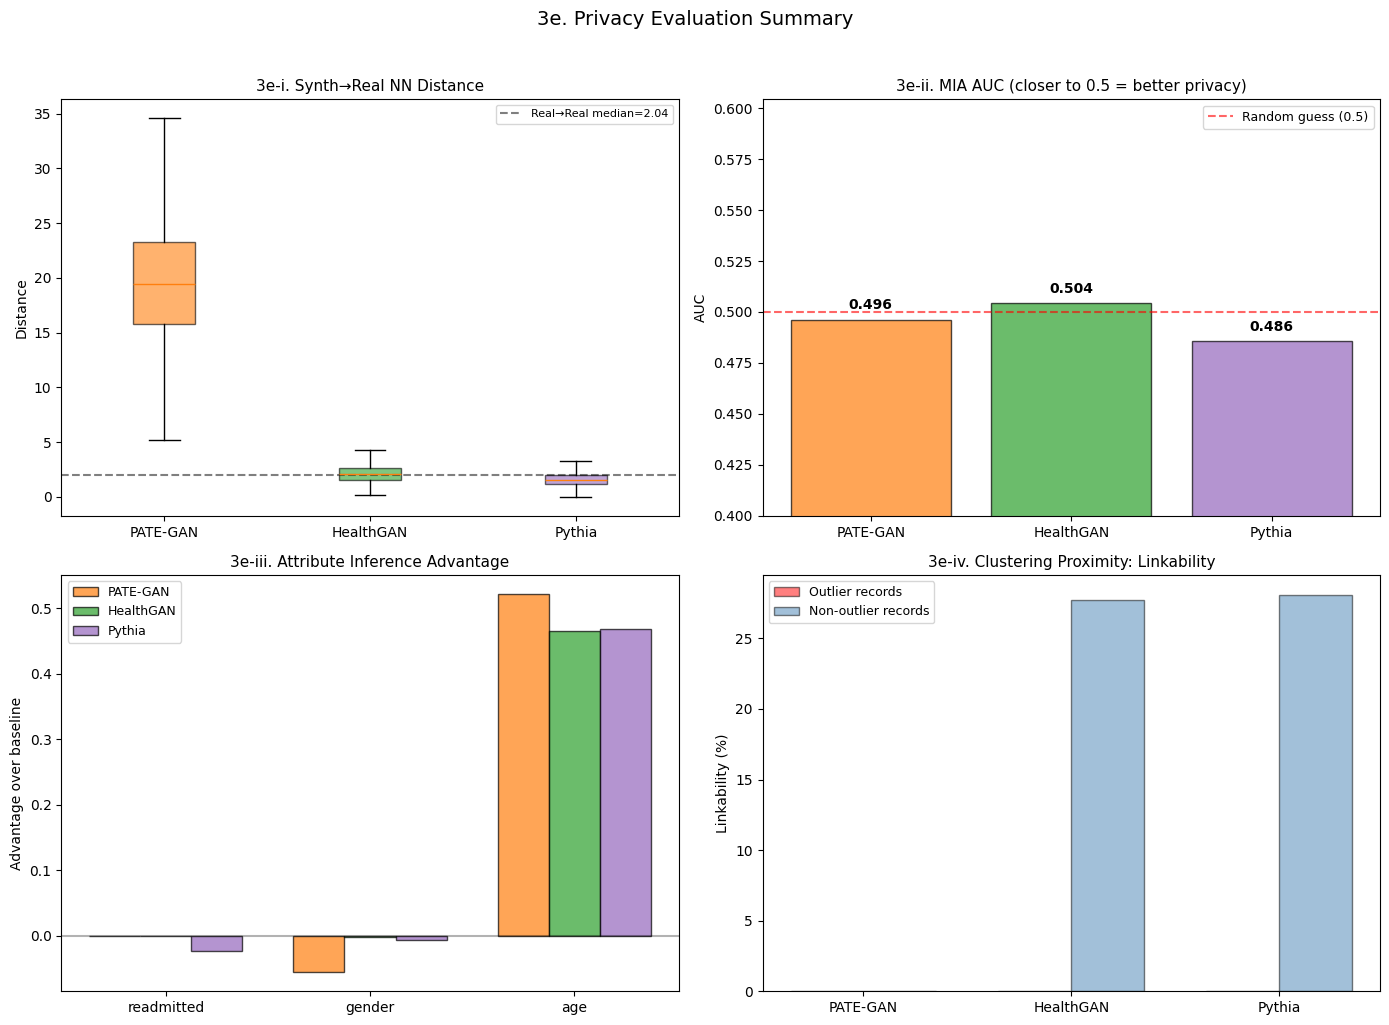

In [24]:
# 3e. Privacy Metrics Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
priv_colors = {'PATE-GAN': 'tab:orange', 'HealthGAN': 'tab:green', 'Pythia': 'tab:purple'}

# --- 1. NN Distance boxplot ---
ax = axes[0, 0]
nn_data = list(s2r_distributions.values())
nn_labels = list(s2r_distributions.keys())
bp = ax.boxplot(nn_data, labels=nn_labels, patch_artist=True, showfliers=False)
for patch, name in zip(bp['boxes'], nn_labels):
    patch.set_facecolor(priv_colors[name])
    patch.set_alpha(0.6)
# Add real→real baseline
real_med = np.median(real_real_nn)
ax.axhline(y=real_med, color='black', linestyle='--', alpha=0.5, label=f'Real→Real median={real_med:.2f}')
ax.set_ylabel("Distance")
ax.set_title("3e-i. Synth→Real NN Distance", fontsize=11)
ax.legend(fontsize=8)

# --- 2. MIA AUC bar chart ---
ax = axes[0, 1]
mia_names = list(mia_results.keys())
mia_aucs = [mia_results[n]['MIA AUC'] for n in mia_names]
bars = ax.bar(mia_names, mia_aucs, color=[priv_colors[n] for n in mia_names], alpha=0.7, edgecolor='black')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.6, label='Random guess (0.5)')
for bar, auc_val in zip(bars, mia_aucs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{auc_val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel("AUC")
ax.set_title("3e-ii. MIA AUC (closer to 0.5 = better privacy)", fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(0.4, max(mia_aucs) + 0.1)

# --- 3. Attribute inference advantage ---
ax = axes[1, 0]
x_pos = np.arange(len(SENSITIVE_ATTRS))
width = 0.25
for i, name in enumerate(synth_map):
    if name in attr_results:
        advantages = [attr_results[name].get(a, {}).get('Advantage', 0) for a in SENSITIVE_ATTRS]
        ax.bar(x_pos + i * width, advantages, width=width, label=name,
               color=priv_colors[name], alpha=0.7, edgecolor='black')
ax.set_xticks(x_pos + width)
ax.set_xticklabels(SENSITIVE_ATTRS, fontsize=10)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.set_ylabel("Advantage over baseline")
ax.set_title("3e-iii. Attribute Inference Advantage", fontsize=11)
ax.legend(fontsize=9)

# --- 4. Clustering proximity: outlier vs non-outlier linkability ---
ax = axes[1, 1]
gen_names = list(cluster_results.keys())
outlier_link = [float(cluster_results[n]['Outlier linkability'].replace('%', '')) for n in gen_names]
non_outlier_link = [float(cluster_results[n]['Non-outlier linkability'].replace('%', '')) for n in gen_names]
x = np.arange(len(gen_names))
w = 0.35
ax.bar(x - w/2, outlier_link, w, label='Outlier records', color='red', alpha=0.5, edgecolor='black')
ax.bar(x + w/2, non_outlier_link, w, label='Non-outlier records', color='steelblue', alpha=0.5, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(gen_names, fontsize=10)
ax.set_ylabel("Linkability (%)")
ax.set_title("3e-iv. Clustering Proximity: Linkability", fontsize=11)
ax.legend(fontsize=9)

fig.suptitle("3e. Privacy Evaluation Summary", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Comparative Summary

Bring all metrics together into a single view for the thesis results chapter.


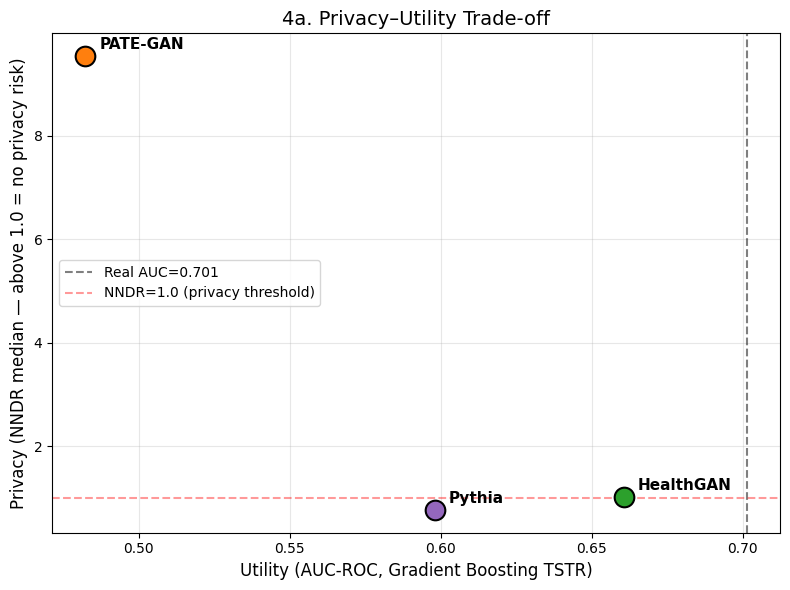

In [28]:
# 4a. Privacy-Utility Trade-off Scatter Plot
# X-axis: Utility (AUC-ROC from Gradient Boosting TSTR)
# Y-axis: Privacy — NNDR median (> 1.0 = synthetic records farther from real than real→real baseline = safe)

gb_results = results_df[results_df['Classifier'] == 'Gradient Boosting'].set_index('Train Source')

trade_off = {}
for name in synth_map:
    auc  = gb_results.loc[name, 'AUC-ROC'] if name in gb_results.index else np.nan
    nndr = nn_privacy.get(name, {}).get('NNDR median', np.nan)
    trade_off[name] = {'AUC-ROC': auc, 'NNDR median': nndr}

trade_df = pd.DataFrame(trade_off).T
scatter_colors = {'PATE-GAN': 'tab:orange', 'HealthGAN': 'tab:green', 'Pythia': 'tab:purple'}

fig, ax = plt.subplots(figsize=(8, 6))
for name in trade_df.index:
    ax.scatter(trade_df.loc[name, 'AUC-ROC'], trade_df.loc[name, 'NNDR median'],
               color=scatter_colors[name], s=200, zorder=3, edgecolors='black', linewidth=1.5)
    ax.annotate(name, (trade_df.loc[name, 'AUC-ROC'], trade_df.loc[name, 'NNDR median']),
                textcoords="offset points", xytext=(10, 5), fontsize=11, fontweight='bold')

real_auc = gb_results.loc['Real (TRTR)', 'AUC-ROC']
ax.axvline(x=real_auc, color='black', linestyle='--', alpha=0.5, label=f'Real AUC={real_auc:.3f}')
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.4, label='NNDR=1.0 (privacy threshold)')

ax.set_xlabel("Utility (AUC-ROC, Gradient Boosting TSTR)", fontsize=12)
ax.set_ylabel("Privacy (NNDR median — above 1.0 = no privacy risk)", fontsize=12)
ax.set_title("4a. Privacy–Utility Trade-off", fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

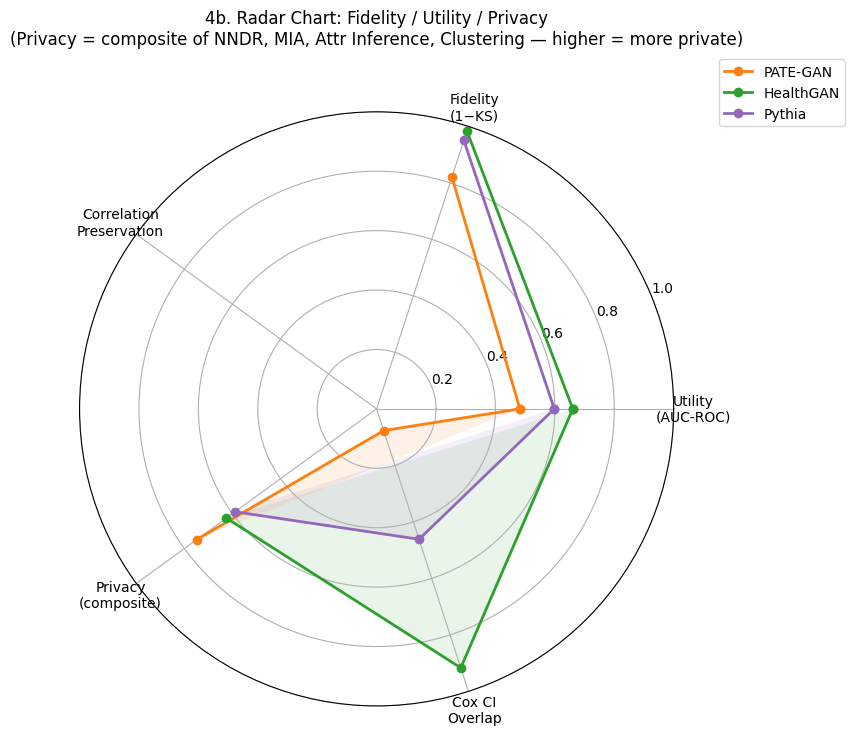


Privacy composite score breakdown:
Generator        NNDR      MIA  AttrInf  Cluster  Composite
PATE-GAN        1.000    0.992    0.000    1.000      0.748
HealthGAN       0.510    0.991    0.000    1.000      0.625
Pythia          0.386    0.972    0.000    1.000      0.589


In [33]:
# 4b. Radar Chart — Fidelity, Utility, Privacy at a glance
# Privacy dimension uses a composite score from all 4 privacy metrics

radar_data = {}
for name in synth_map:
    auc = gb_results.loc[name, 'AUC-ROC'] if name in gb_results.index else 0
    mean_ks = ks_df[f'{name}_KS'].mean()

    # Correlation preservation
    corr_diff = (real_corr - synth_map[name].corr()).abs()
    corr_score = 1 - corr_diff.values[np.tril_indices_from(corr_diff.values, k=-1)].mean()

    # Cox CI overlap fraction
    cox_overlap = 0
    if name in cox_results and 'Real' in cox_results:
        rhr = cox_results['Real']
        shr = cox_results[name]
        common = [c for c in rhr.index if c in shr.index]
        if common:
            overlapping = sum(1 for c in common
                              if not (rhr.loc[c, 'CI_upper'] < shr.loc[c, 'CI_lower']
                                      or shr.loc[c, 'CI_upper'] < rhr.loc[c, 'CI_lower']))
            cox_overlap = overlapping / len(common)

    # --- Composite privacy score (4 components, each in [0,1]) ---
    # 1. NNDR: normalize by capping at 2.0 (NNDR=2 → score=1, NNDR=0.5 → score=0.25)
    nndr_val = nn_privacy.get(name, {}).get('NNDR median', 0)
    nndr_score = min(nndr_val / 2.0, 1.0)

    # 2. MIA: deviation from 0.5 (AUC=0.5→score=1, AUC=0.75→score=0.5, AUC=1.0→score=0)
    mia_auc_val = mia_results.get(name, {}).get('MIA AUC', 0.5)
    mia_score = max(0.0, 1.0 - 2.0 * abs(mia_auc_val - 0.5))

    # 3. Attribute inference: 0 advantage → score=1; normalize by 0.2 ceiling
    max_attr_adv = 0
    if name in attr_results:
        advs = [v.get('Advantage', 0) for v in attr_results[name].values()]
        max_attr_adv = max(advs) if advs else 0
    attr_score = max(0.0, 1.0 - max_attr_adv / 0.2)

    # 4. Clustering proximity: 0% outlier linkability → score=1
    outlier_link_str = cluster_results.get(name, {}).get('Outlier linkability', '100%')
    outlier_link_frac = float(outlier_link_str.replace('%', '')) / 100.0
    cluster_score = 1.0 - outlier_link_frac

    privacy_composite = (nndr_score + mia_score + attr_score + cluster_score) / 4.0

    radar_data[name] = {
        'Utility\n(AUC-ROC)': auc,
        'Fidelity\n(1−KS)': 1 - mean_ks,
        'Correlation\nPreservation': corr_score,
        'Privacy\n(composite)': privacy_composite,
        'Cox CI\nOverlap': cox_overlap,
    }

radar_df = pd.DataFrame(radar_data)
categories = list(radar_df.index)
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
radar_colors = {'PATE-GAN': 'tab:orange', 'HealthGAN': 'tab:green', 'Pythia': 'tab:purple'}

for name in radar_df.columns:
    values = radar_df[name].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=name, color=radar_colors[name])
    ax.fill(angles, values, alpha=0.1, color=radar_colors[name])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title("4b. Radar Chart: Fidelity / Utility / Privacy\n"
             "(Privacy = composite of NNDR, MIA, Attr Inference, Clustering — higher = more private)",
             fontsize=12, y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

# Print the component scores for transparency
print("\nPrivacy composite score breakdown:")
print(f"{'Generator':<12} {'NNDR':>8} {'MIA':>8} {'AttrInf':>8} {'Cluster':>8} {'Composite':>10}")
for name in synth_map:
    nndr_val = nn_privacy.get(name, {}).get('NNDR median', 0)
    n_s = min(nndr_val / 2.0, 1.0)
    mia_auc_val = mia_results.get(name, {}).get('MIA AUC', 0.5)
    m_s = max(0.0, 1.0 - 2.0 * abs(mia_auc_val - 0.5))
    max_attr_adv = max([v.get('Advantage', 0) for v in attr_results.get(name, {}).values()], default=0)
    a_s = max(0.0, 1.0 - max_attr_adv / 0.2)
    outlier_link_str = cluster_results.get(name, {}).get('Outlier linkability', '100%')
    c_s = 1.0 - float(outlier_link_str.replace('%', '')) / 100.0
    comp = (n_s + m_s + a_s + c_s) / 4.0
    print(f"{name:<12} {n_s:>8.3f} {m_s:>8.3f} {a_s:>8.3f} {c_s:>8.3f} {comp:>10.3f}")

In [34]:
# 4c. Comprehensive Summary Table — All metrics in one view
summary_rows = []
for name in synth_map:
    row = {'Generator': name}

    # Fidelity
    row['Mean KS Stat ↓'] = ks_df[f'{name}_KS'].mean()
    corr_diff = (real_corr - synth_map[name].corr()).abs()
    row['Mean Corr Diff ↓'] = corr_diff.values[np.tril_indices_from(corr_diff.values, k=-1)].mean()

    # Utility (Gradient Boosting)
    if name in gb_results.index:
        row['AUC-ROC ↑'] = gb_results.loc[name, 'AUC-ROC']
    gb_f1 = results_df[(results_df['Classifier'] == 'Gradient Boosting') &
                        (results_df['Train Source'] == name)]
    if len(gb_f1) > 0:
        row['F1 ↑'] = gb_f1.iloc[0]['F1']

    # Cox CI overlap — stored as float fraction (0–1)
    if name in cox_results and 'Real' in cox_results:
        rhr = cox_results['Real']
        shr = cox_results[name]
        common_c = [c for c in rhr.index if c in shr.index]
        if common_c:
            overlapping = sum(1 for c in common_c
                              if not (rhr.loc[c, 'CI_upper'] < shr.loc[c, 'CI_lower']
                                      or shr.loc[c, 'CI_upper'] < rhr.loc[c, 'CI_lower']))
            row['Cox CI Overlap ↑'] = overlapping / len(common_c)

    # Privacy — NN Distances
    nn_met = nn_privacy.get(name, {})
    row['NN Dist Median ↑'] = nn_met.get('Synth→Real median', np.nan)
    row['NNDR Median ↑'] = nn_met.get('NNDR median', np.nan)

    # Privacy — MIA
    mia_met = mia_results.get(name, {})
    row['MIA AUC ≈0.5'] = mia_met.get('MIA AUC', np.nan)
    row['MIA Advantage ↓'] = mia_met.get('MIA Advantage', np.nan)

    # Privacy — Attribute Inference (max advantage across attributes)
    if name in attr_results:
        advs = [v.get('Advantage', 0) for v in attr_results[name].values()]
        row['Max Attr Inf Adv ↓'] = max(advs) if advs else np.nan

    # Privacy — Clustering Proximity (convert "45.2%" → 45.2 float)
    cl = cluster_results.get(name, {})
    outlier_link_str = cl.get('Outlier linkability', None)
    if outlier_link_str is not None:
        row['Outlier Link% ↓'] = float(outlier_link_str.replace('%', ''))
    else:
        row['Outlier Link% ↓'] = np.nan

    summary_rows.append(row)

# Add real baseline
real_row = {'Generator': 'Real (TRTR)'}
if 'Real (TRTR)' in gb_results.index:
    real_row['AUC-ROC ↑'] = gb_results.loc['Real (TRTR)', 'AUC-ROC']
real_gb_f1 = results_df[(results_df['Classifier'] == 'Gradient Boosting') &
                         (results_df['Train Source'] == 'Real (TRTR)')]
if len(real_gb_f1) > 0:
    real_row['F1 ↑'] = real_gb_f1.iloc[0]['F1']
summary_rows.insert(0, real_row)

summary_table = pd.DataFrame(summary_rows).set_index('Generator')

# Per-column format: Outlier Link% is a percentage (0–100); Cox CI Overlap is a fraction (0–1)
fmt = {col: "{:.4f}" for col in summary_table.columns}
if 'Outlier Link% ↓' in summary_table.columns:
    fmt['Outlier Link% ↓'] = "{:.1f}%"

print("4c. Comprehensive Summary — All Metrics")
print("(↑ = higher is better, ↓ = lower is better, ≈0.5 = closer to 0.5 is better)")
display(summary_table.style.format(fmt, na_rep="—").set_caption(
    "Fidelity / Utility / Privacy Metrics: Real vs PATE-GAN vs HealthGAN vs Pythia"))

4c. Comprehensive Summary — All Metrics
(↑ = higher is better, ↓ = lower is better, ≈0.5 = closer to 0.5 is better)


,AUC-ROC ↑,F1 ↑,Mean KS Stat ↓,Mean Corr Diff ↓,Cox CI Overlap ↑,NN Dist Median ↑,NNDR Median ↑,MIA AUC ≈0.5,MIA Advantage ↓,Max Attr Inf Adv ↓,Outlier Link% ↓
Generator,,,,,,,,,,,
Real (TRTR),0.7014,0.3644,—,—,—,—,—,—,—,—,—
PATE-GAN,0.4823,0.0437,0.1797,—,0.0769,19.4258,9.5360,0.4962,-0.0038,0.5224,0.0%
HealthGAN,0.6605,0.2647,0.0165,—,0.9167,2.0910,1.0196,0.5043,0.0043,0.4662,0.0%
Pythia,0.5981,0.3944,0.0498,—,0.4615,1.5674,0.7712,0.4858,-0.0142,0.4686,0.0%
